In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
from scipy.ndimage import binary_dilation

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-04-28 13:09:25.743382: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [19]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/IO/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/IO/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/IO/calslope/"
    uncal_path = "/Users/mcha5804/JWST/IO/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/IO/")
output_path = os.path.join(cache, "outputs/io/")

state = np.load(os.path.join(model_cache, "static_model.npy"), allow_pickle=True).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
def truncate_files(files, ngroups):
    """
    Truncate the ramp of files to only have ngroups.
    """
    # TODO do one_on_fs here

    for file in files:

        top_group = file["RAMP"].data.shape[0]
        up_to = top_group - ngroups

        # files are mutable, so they will change in place
        for attr in ["RAMP", "SLOPE", "RAMP_ERR", "RAMP_SUP", "SLOPE_SUP"]:
            file[attr].data = file[attr].data[:-up_to, ...]

        file["SLOPE_ERR"].data = file["SLOPE_ERR"].data[:-up_to, :-up_to, ...]

In [4]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # badpix = np.array(file["BADPIX"].data, dtype=bool)
    # im = np.array(file["SLOPE"].data.sum(0))
    # im = np.where(badpix, np.nan, im)
    # mask = binary_dilation(im == np.nanmax(im), iterations=2)
    # file["BADPIX"].data += mask.astype(int)

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
# dorito.misc.truncate_files(sci_files, 18)
truncate_files(sci_files, 18)

In [5]:
source_size = 112
# level = 5
# # shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
# wavelets = dorito.wavelets.Wavelets(
#     np.ones((source_size, source_size)), level=level, wavelet="db2"
# )

dfnrnn_model = amigo.ramp_models.DFRNN(jr.key(0))
ramp_model = amigo.ramp_models.RNNRamp(
    dfnrnn_model, gain_model=amigo.detector_models.PixelSensitivity(), norm=2**14
)

model, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    cal_files,
    # [],
    # sci_files[3:4],
    # cal_files,
    sci_files,
    # [],
    state=state,
    source_size=source_size,
    rolls_dict=rolls,
    ramp_model=ramp_model,
    modeller=dorito.models.ResolvedAmigoModel,
    # modeller=WaveletModel,
    # wavelets=wavelets,
    separate_fits=True,
    cal_fit=dorito.model_fits.PointFit,
    # cal_fit=UniqueAbFit,
    sci_fit=dorito.model_fits.DynamicResolvedFit,
    # sci_fit=dorito.model_fits.ResolvedFit,
    rotate=False,
    # downsample=False,
    source_oversample=1,
)
fits = [*cal_fits, *sci_fits]

# # init state
# init_state = np.load(init_state_cache + "allcals.npy", allow_pickle=True)[()]
# for p in [
#     "positions",
#     "fluxes",
#     "aberrations",
#     "spectra",
#     # "log_distribution",
# ]:
#     for key in init_state[p].keys():
#         params[p][key] = init_state[p][key]

# params[p] = init_state[p]


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x


model = jax.tree.map(fn, model)

In [6]:
pos_keys = []
spc_keys = []
for exp in fits:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def kill_pos_grads(model, grads, args):
    grads = grads.multiply(pos_keys, 0)
    # grads = grads.multiply(pos_keys, 1e-3)
    grads = grads.multiply(spc_keys, 1e-2)
    return grads, args


eps = 1e1


def term_looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.4e}")

    if len(list(loss_dict.values())[0]) > 10:
        last_loss = np.array([v[-2] for v in loss_dict.values()]).mean(0)
        if np.abs(last_loss - loss) < eps:
            return True

    return False


def normalise_distribution(model_params, args):
    params = model_params.params
    if "log_distribution" in params.keys():
        for k, log_dist in params["log_distribution"].items():
            distribution = 10**log_dist
            params["log_distribution"][k] = np.log10(distribution / distribution.sum())

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args

In [7]:
n_epoch = 500

config = {
    "positions": sgd(4e-2, 0),
    "fluxes": sgd(2e-1, 0),
    "spectra": sgd(3e-2, 10),
    "aberrations": sgd(3e-2, 4),
    "log_distribution": adam(5e-2, 20),  # , (10, 0.25), b1=0.7),
    # "log_distribution": adam(7e-2, 0),  # , (10, 0.25), b1=0.7),,
    # "approx": adam(1e-5, 0),
    # "details": adam(6e-9, 15),
}

reg_dict = {
    # "L1": 2.0e3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e6,
    # "QV": 1.0e-3,
    # "ME": 1.0e2,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        # "L1": dorito.stats.L1_on_wavelets,
        # "L1": L1_on_wavelets,
        # "QV": dorito.stats.TSV,
        # "ME": dorito.stats.ME,
    },
    # "mask": mask,
}

trainer = amigo.fitting.Trainer(
    loss_fn=dorito.stats.regularised_loss_fn,
    norm_fn=normalise_distribution,
    grad_fn=kill_pos_grads,
    cache=fisher_cache,
    looper_fn=term_looper,
)

trainer = trainer.update_fishers(
    model.set("detector.ramp.bleed", False),
    # model,
    fits,
    args=args,
    verbose=True,
    parameters=[
        "positions",
        "fluxes",
        "aberrations",
        "spectra",
        # "one_on_fs",
        # "log_distribution",
        # "spectral_coeffs",
    ],
    # recalculate=True,
)

# Train the model
result = trainer.train(
    model=model,
    # model=model.set("detector.ramp.values", np.zeros_like(model.ramp.values)),
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    args=args,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 191,204,641.20
Estimated run time: 0:10:22
Full Time: 0:11:41
Final Loss: 284,060.60


In [ ]:
pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample


def summarise_reconstruction(model, fits, result=None):

    ticks = [
        -0.5,
        0,
        0.5,
    ]

    flag = False
    for exp in fits:

        if not flag and exp.calibrator is False:
            try:
                dist = model.get_distribution(exp)
            except:
                dist = exp.get_distribution(model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                pixel_scale=pscale(model),
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                vmin=0,
                ticks=ticks,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, model, exp, factor=0.5),
                pixel_scale=pscale(model),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
                ticks=ticks,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            # pa = model.params["position_angles"][exp.key]
            ax[0].set_title(
                f"Io - {exp.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
            )
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(output_path + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
            if type(sci_fits[0]) != dorito.model_fits.DynamicResolvedFit:
                flag = True

    try:
        amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
        amigo.plotting.plot(result.history)
    except:
        pass

    for exp in fits:
        exp.print_summary()

        if exp.ngroups > 2:
            amigo.plotting.summarise_fit(
                model,
                exp,
                # residuals=True,
            )

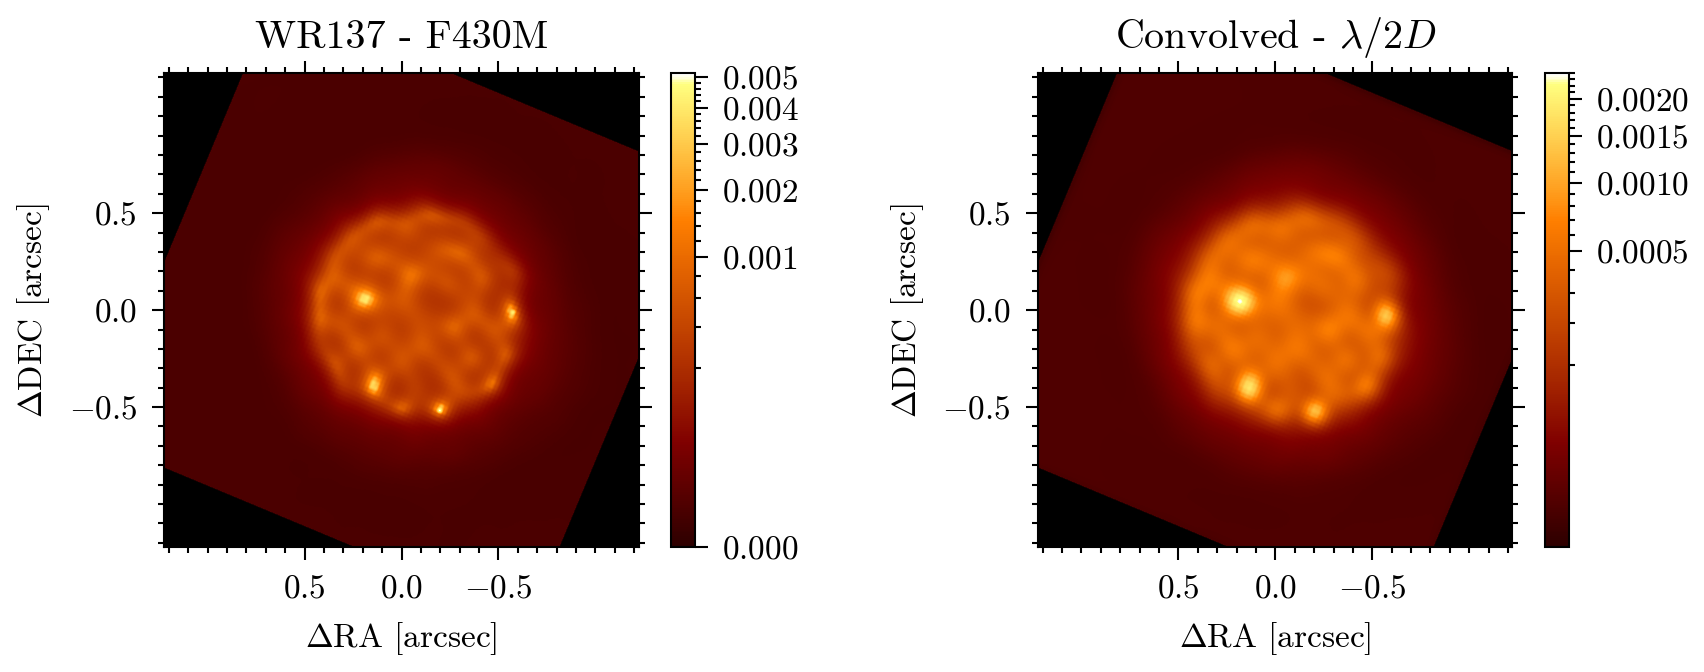

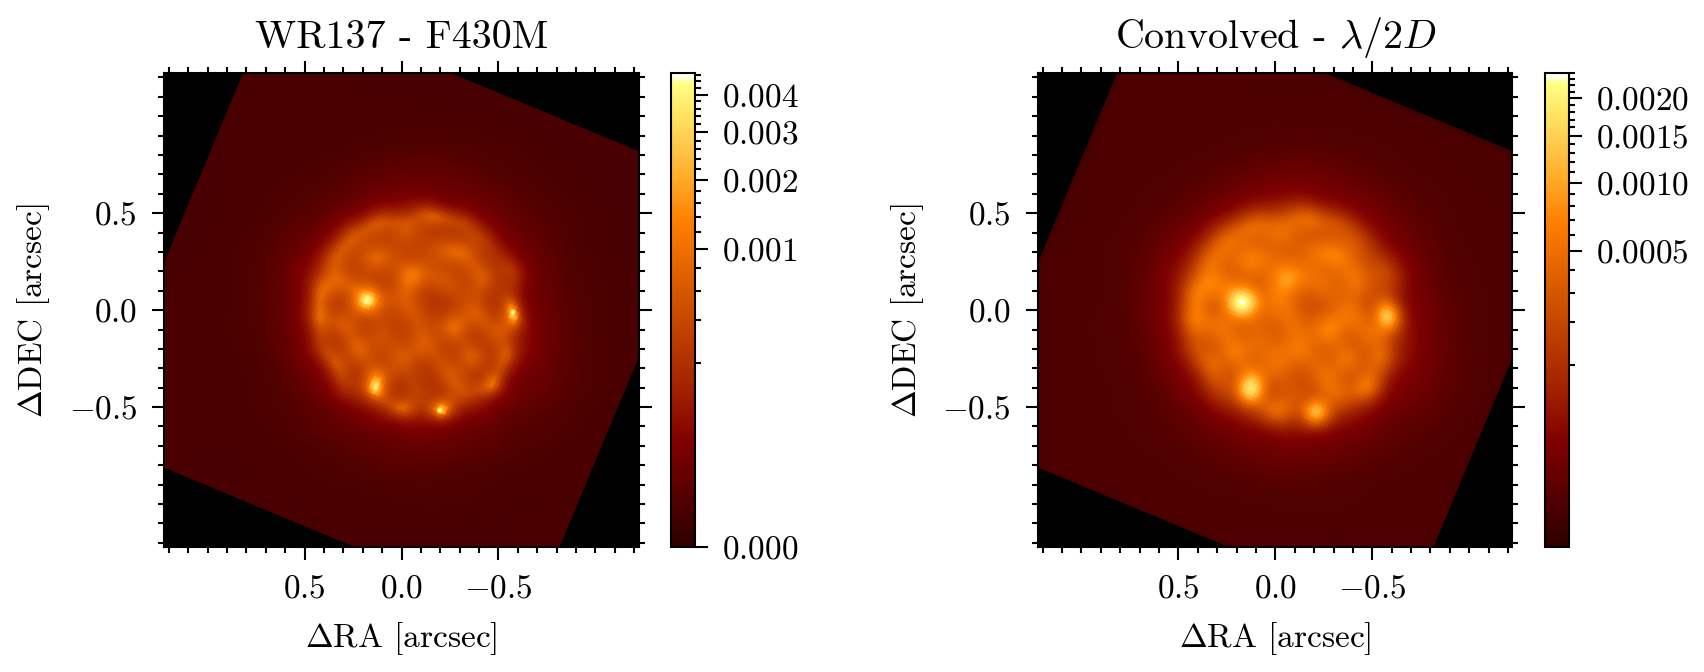

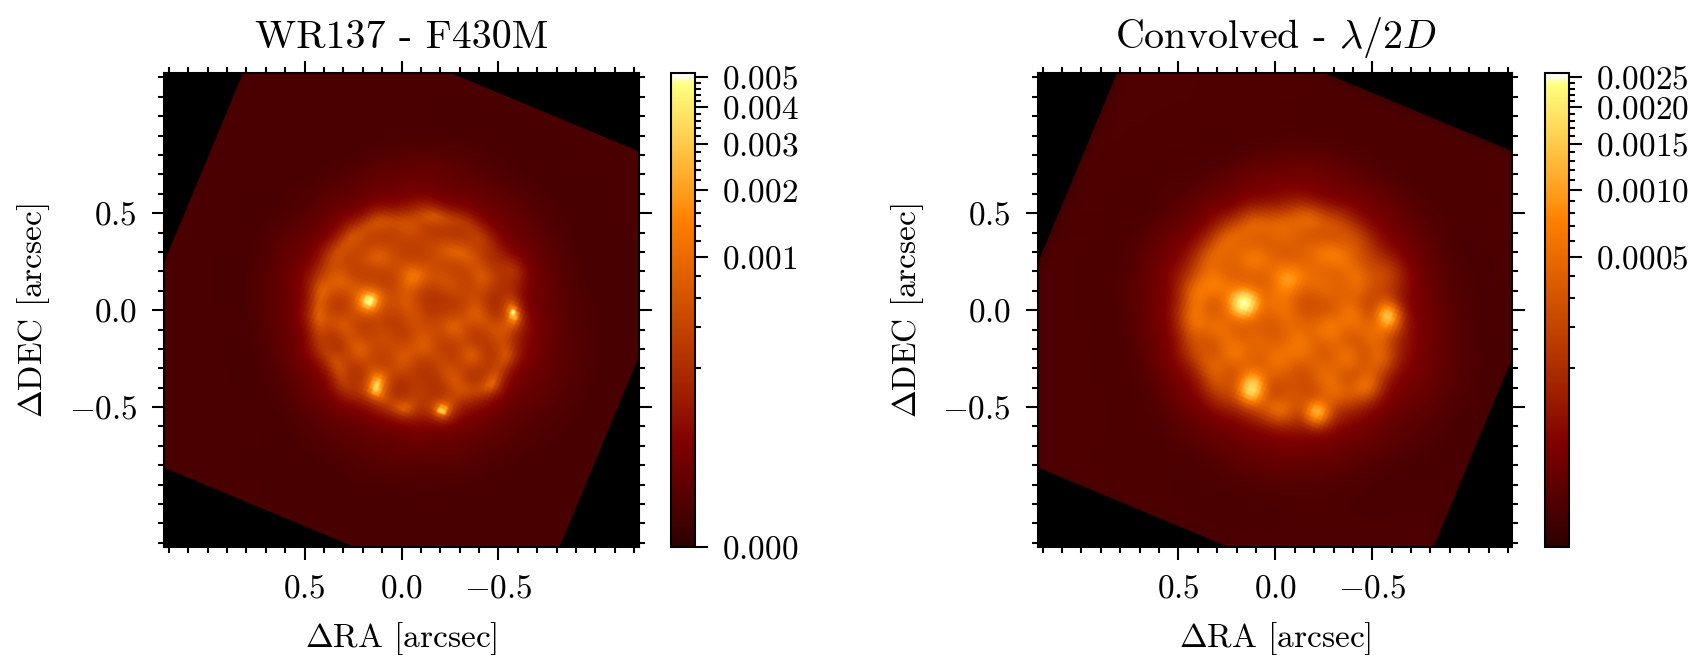

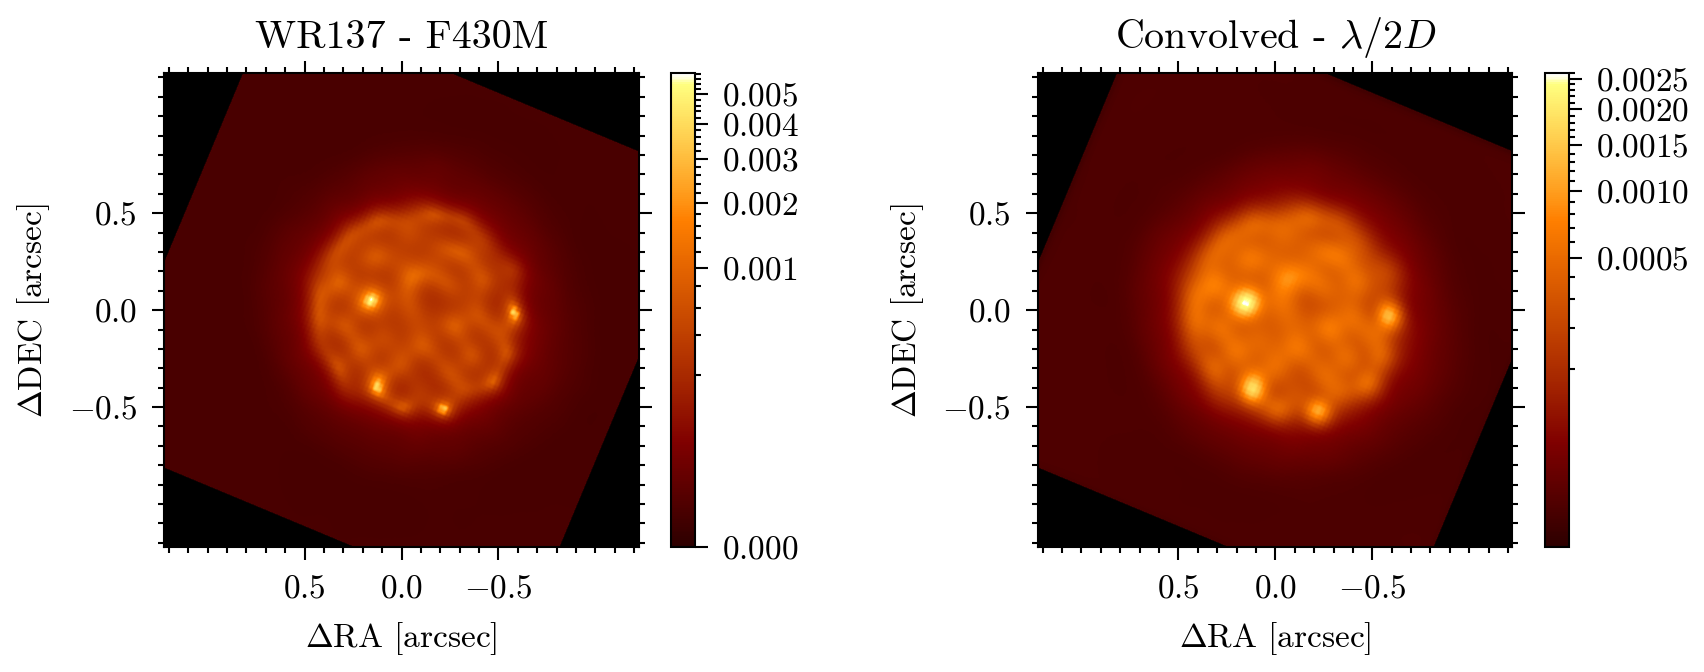

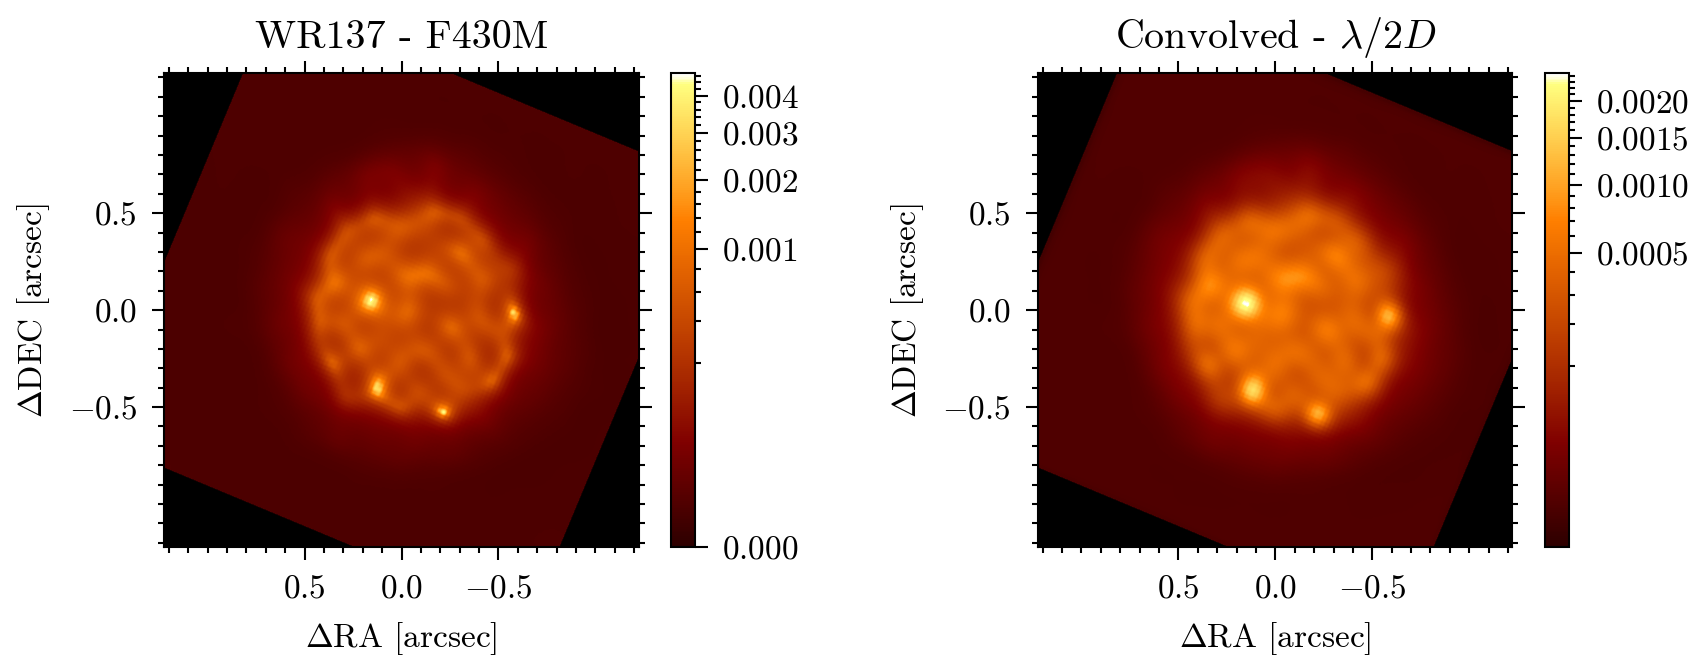

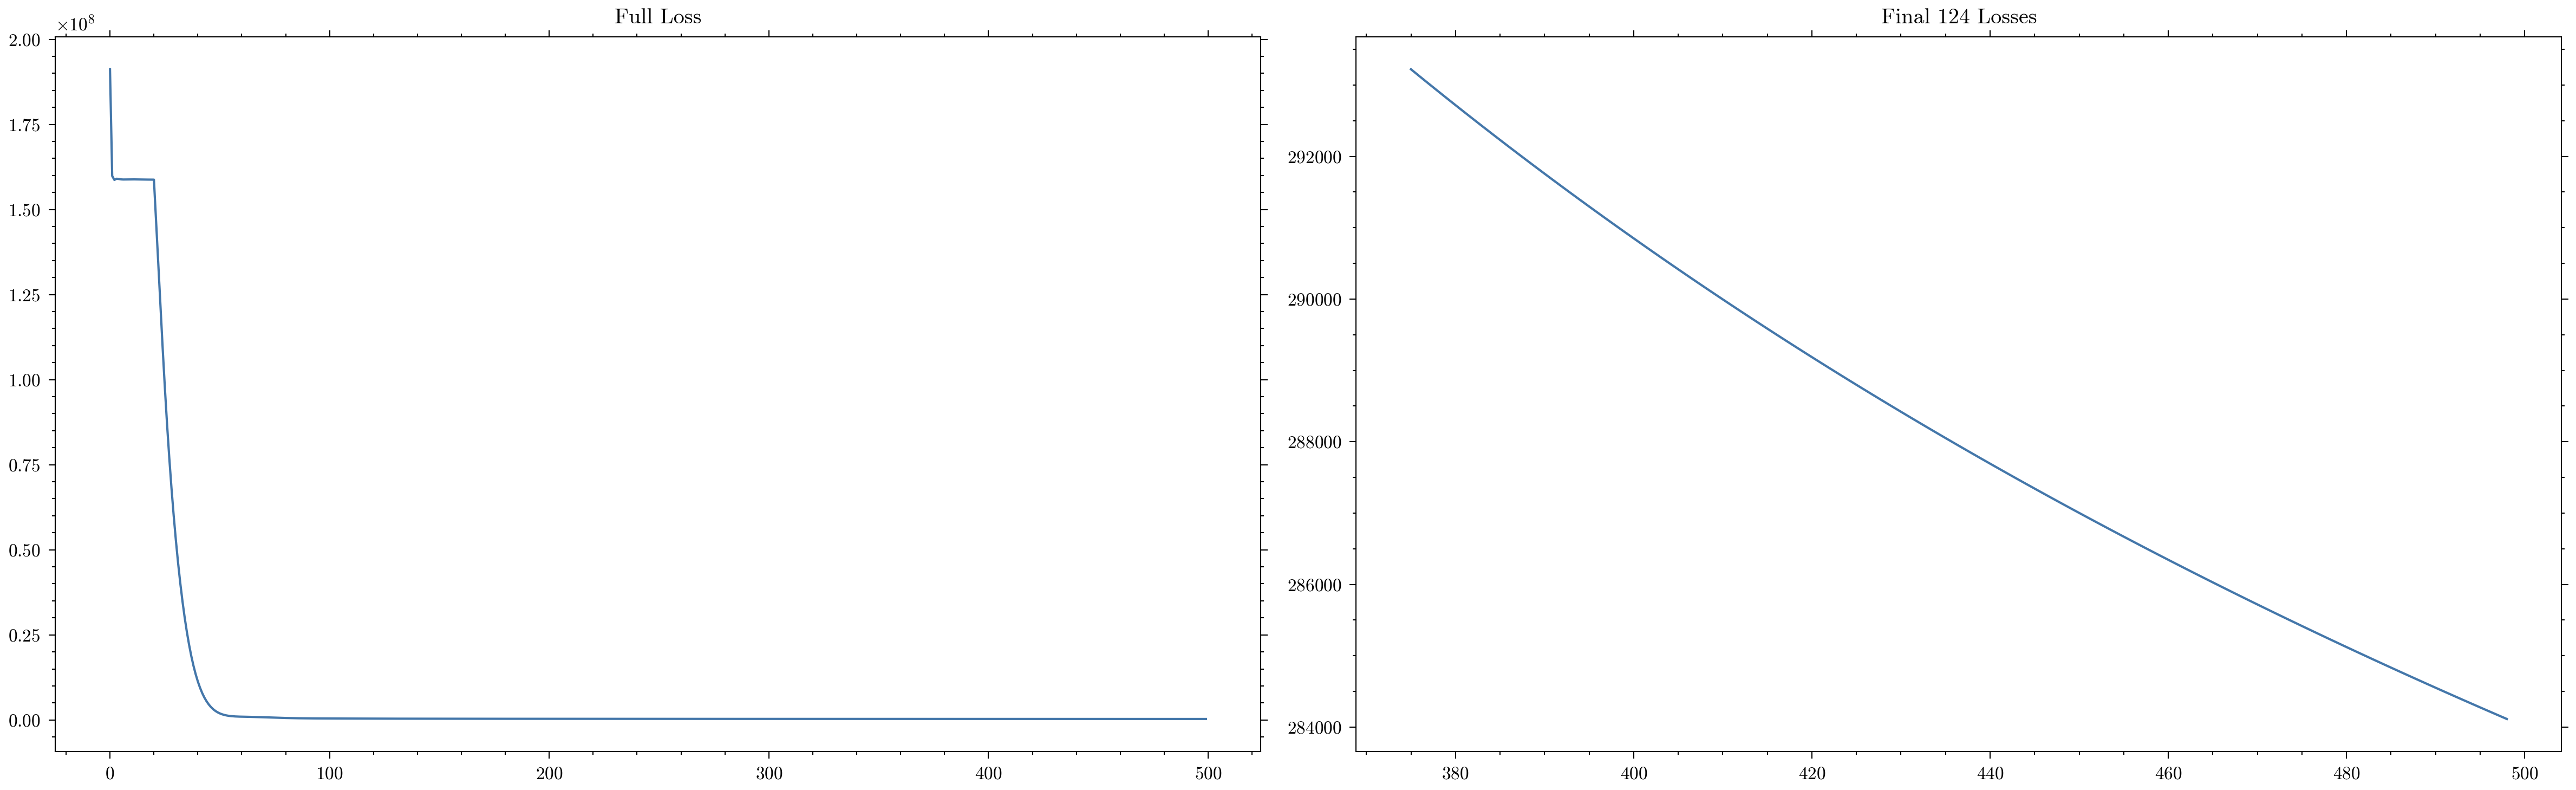

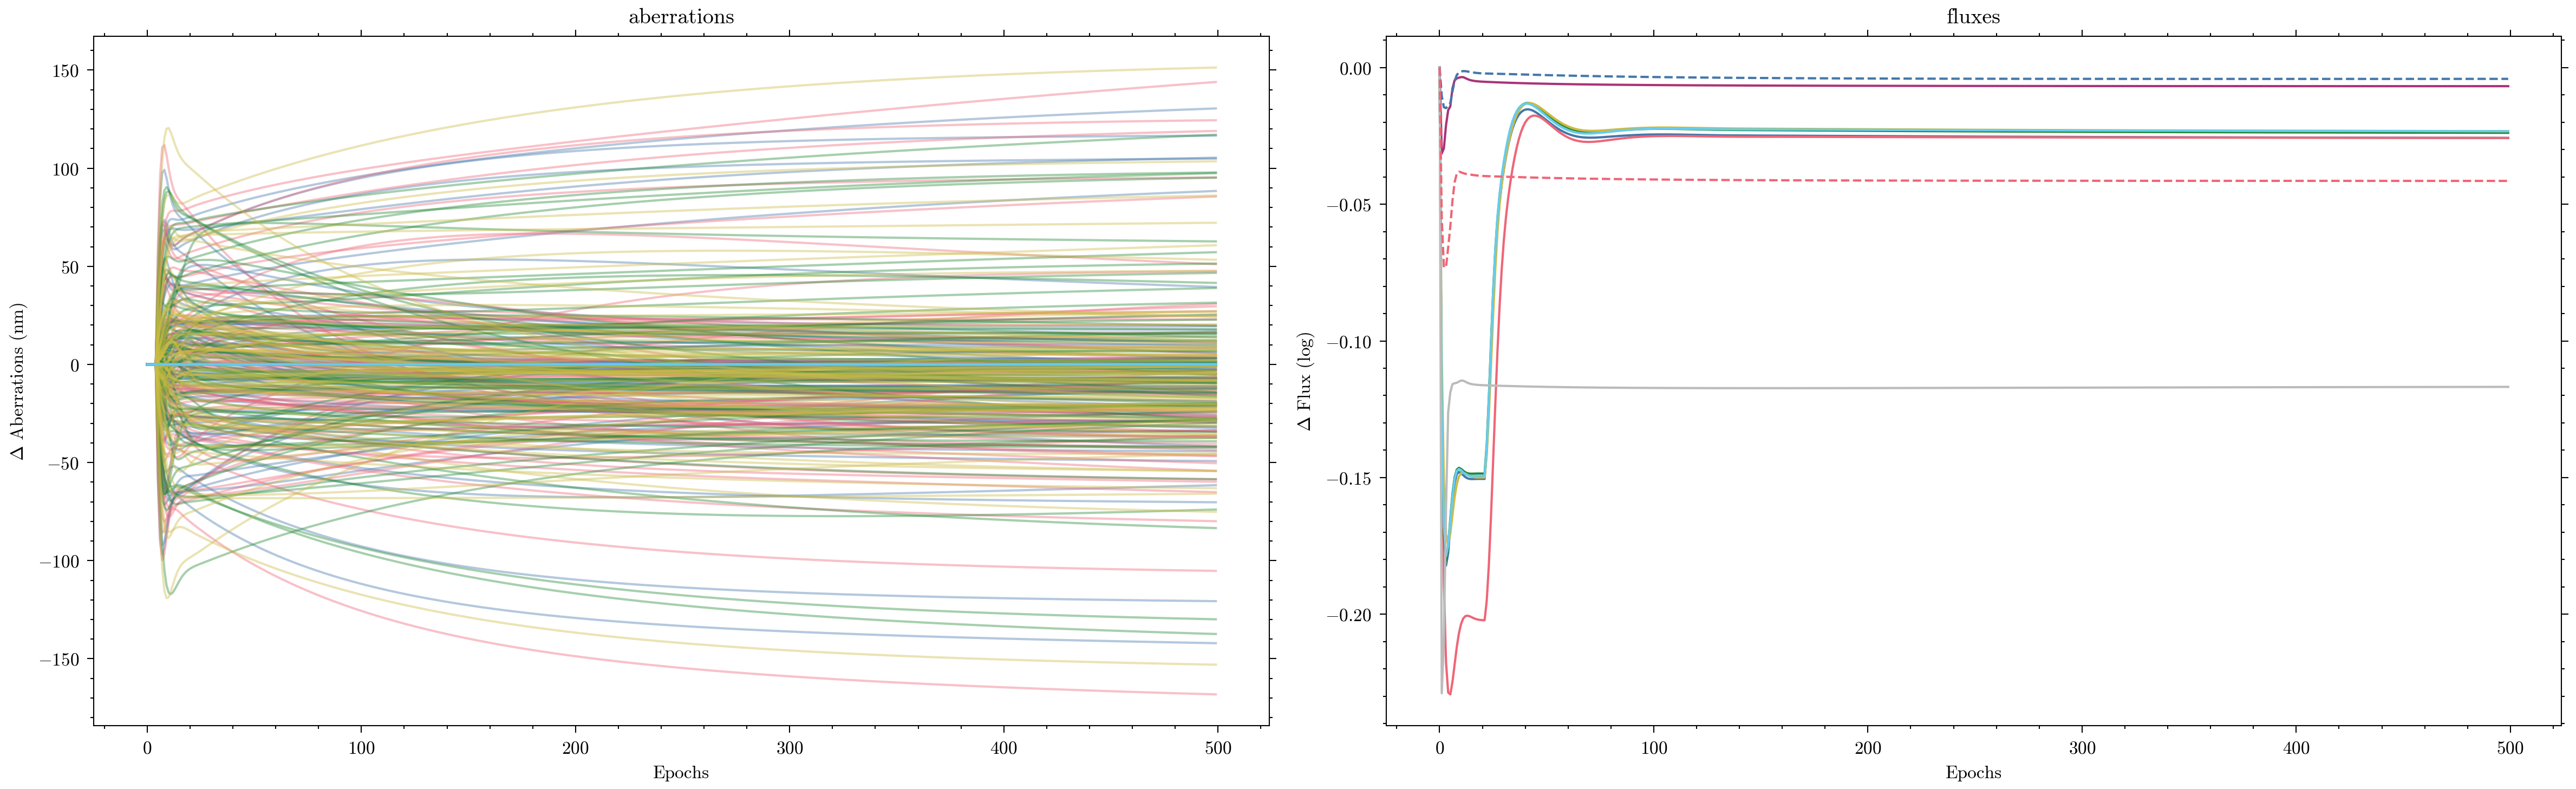

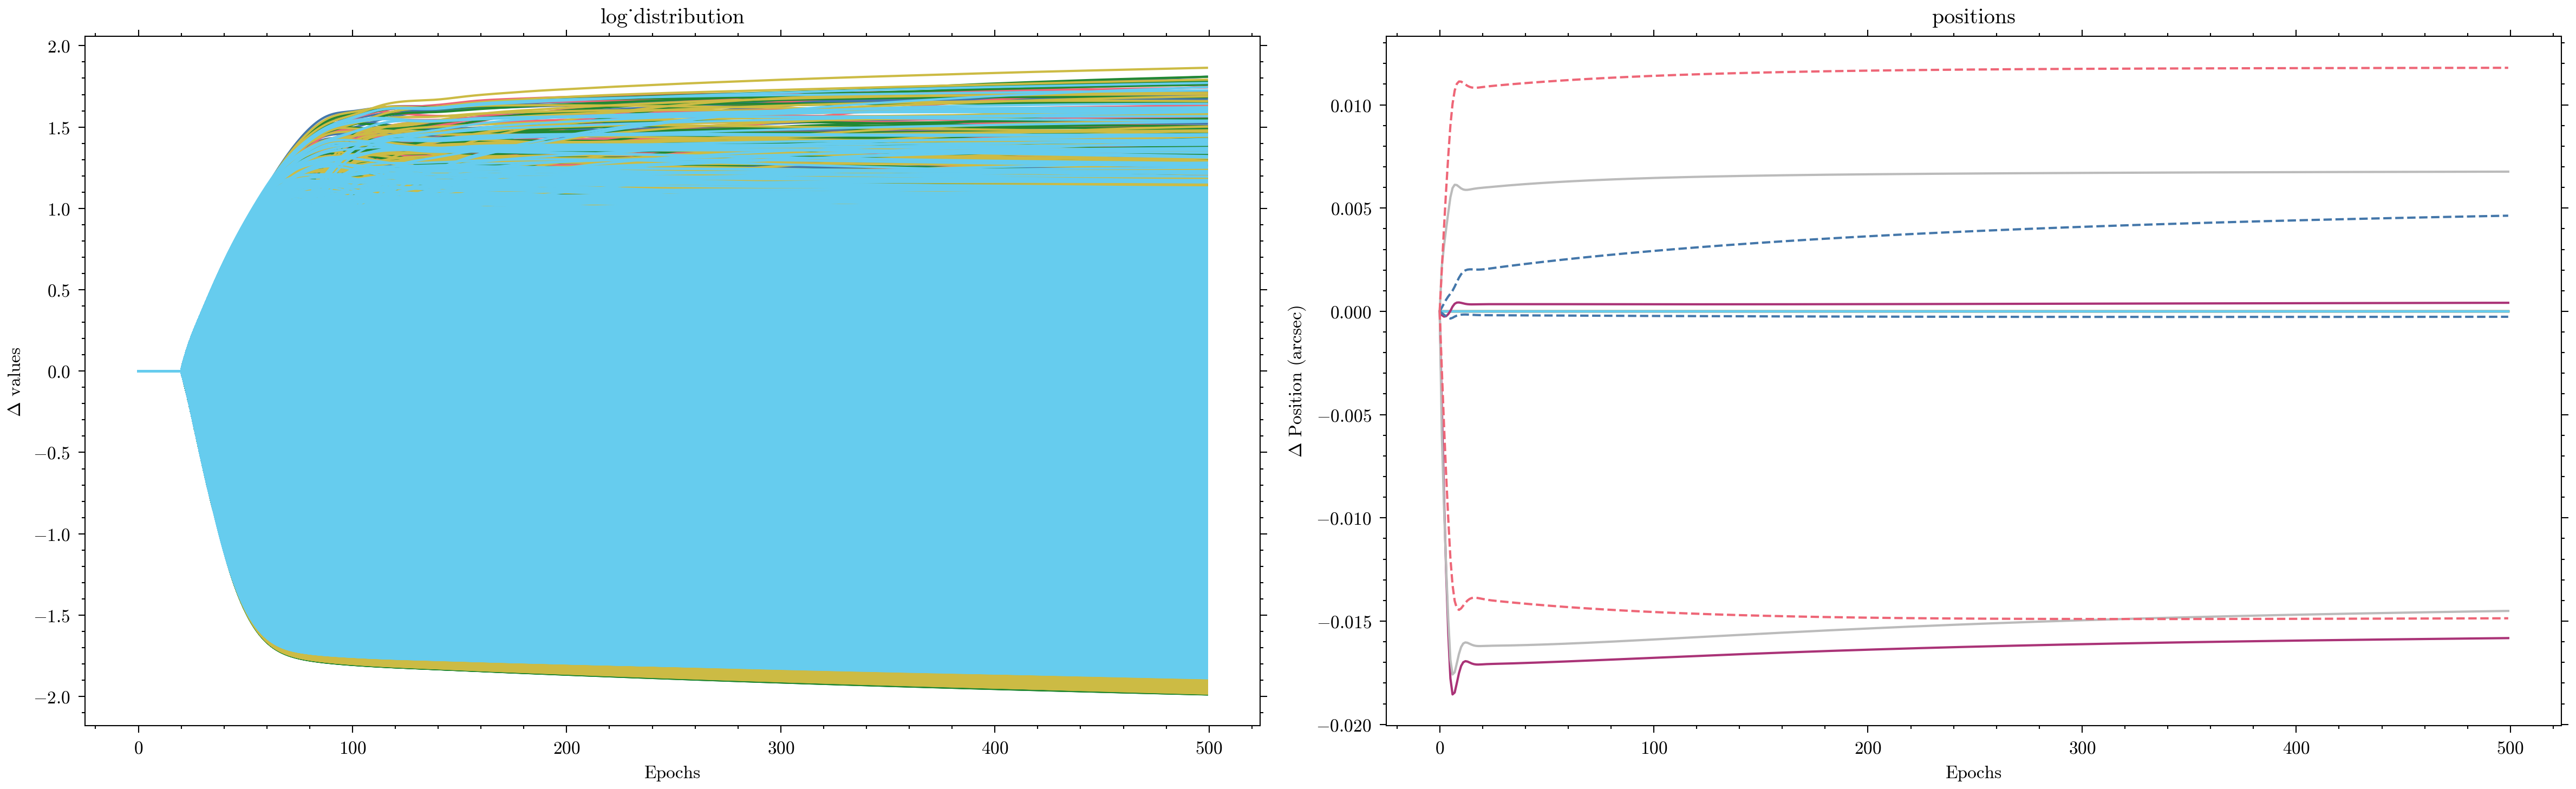

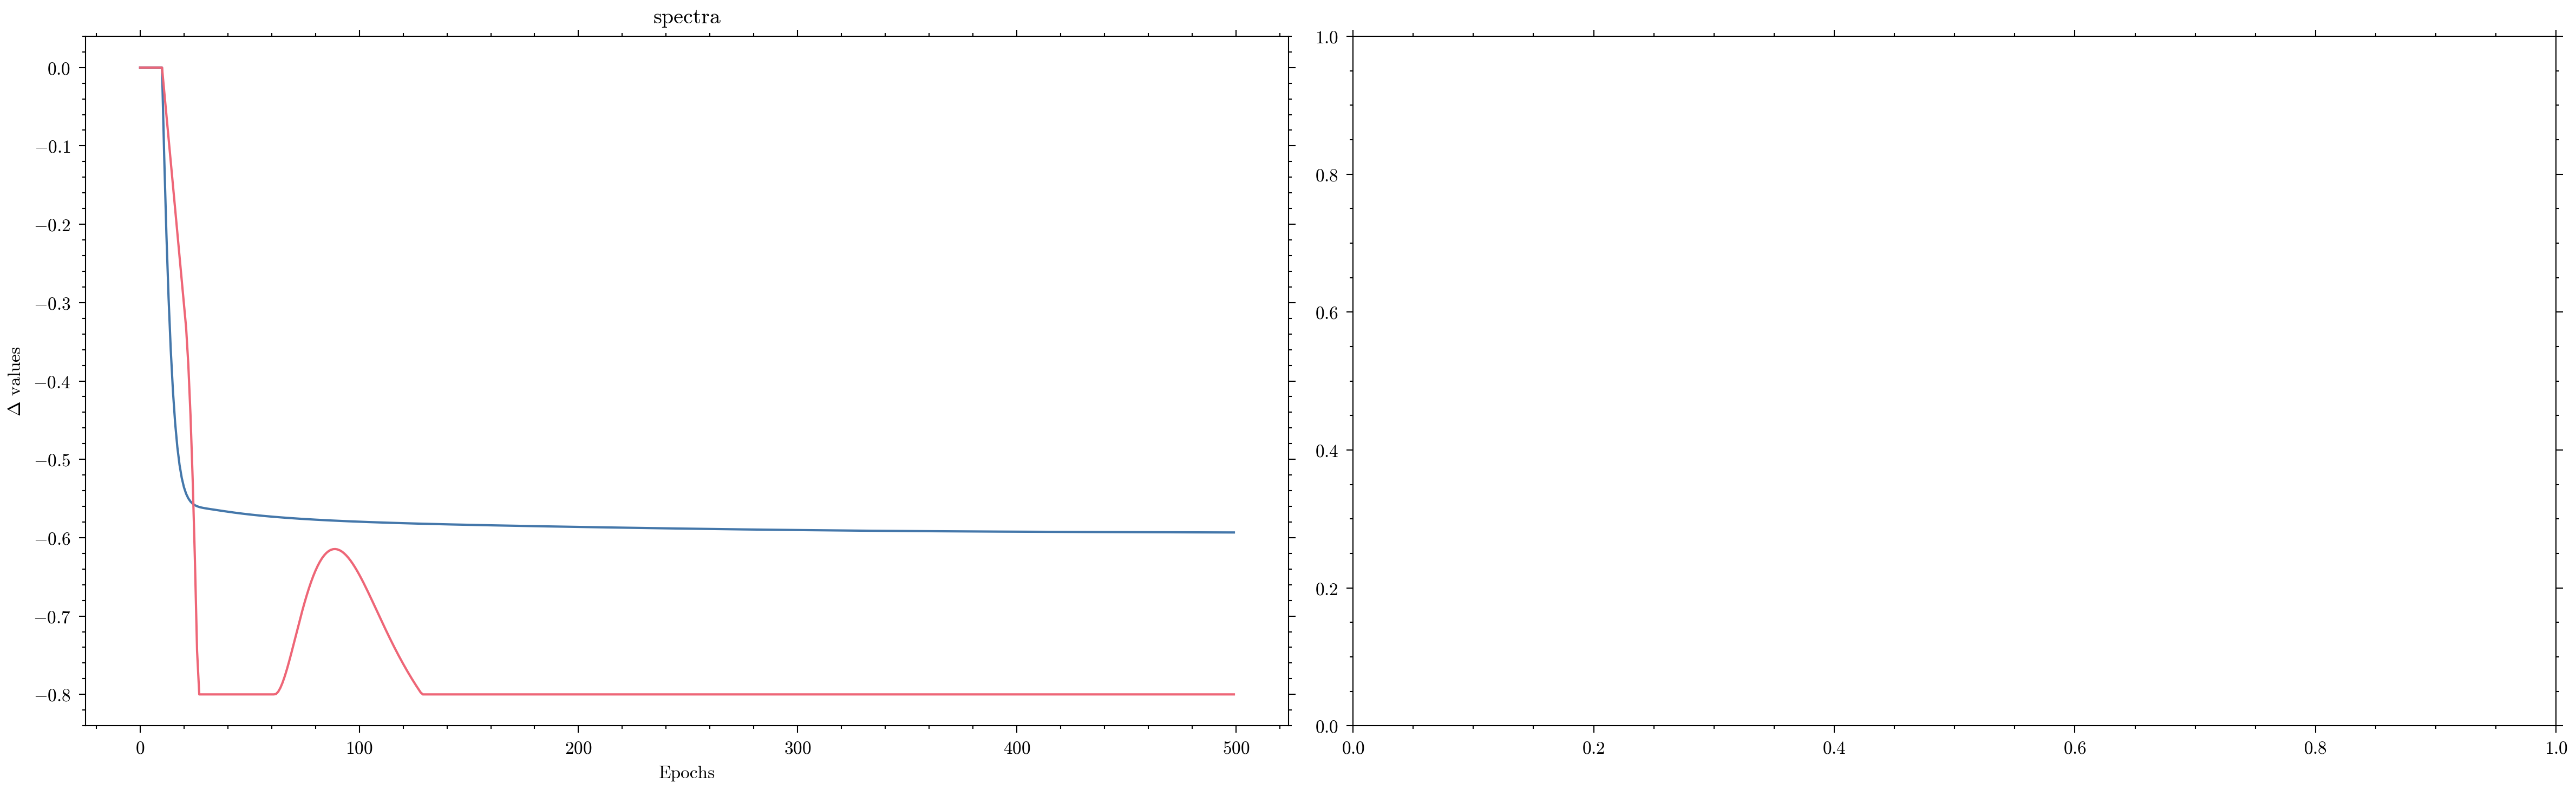

File 01373_023_02_03_1
Star HD 2236
Filter F430M
nints 8
ngroups 12



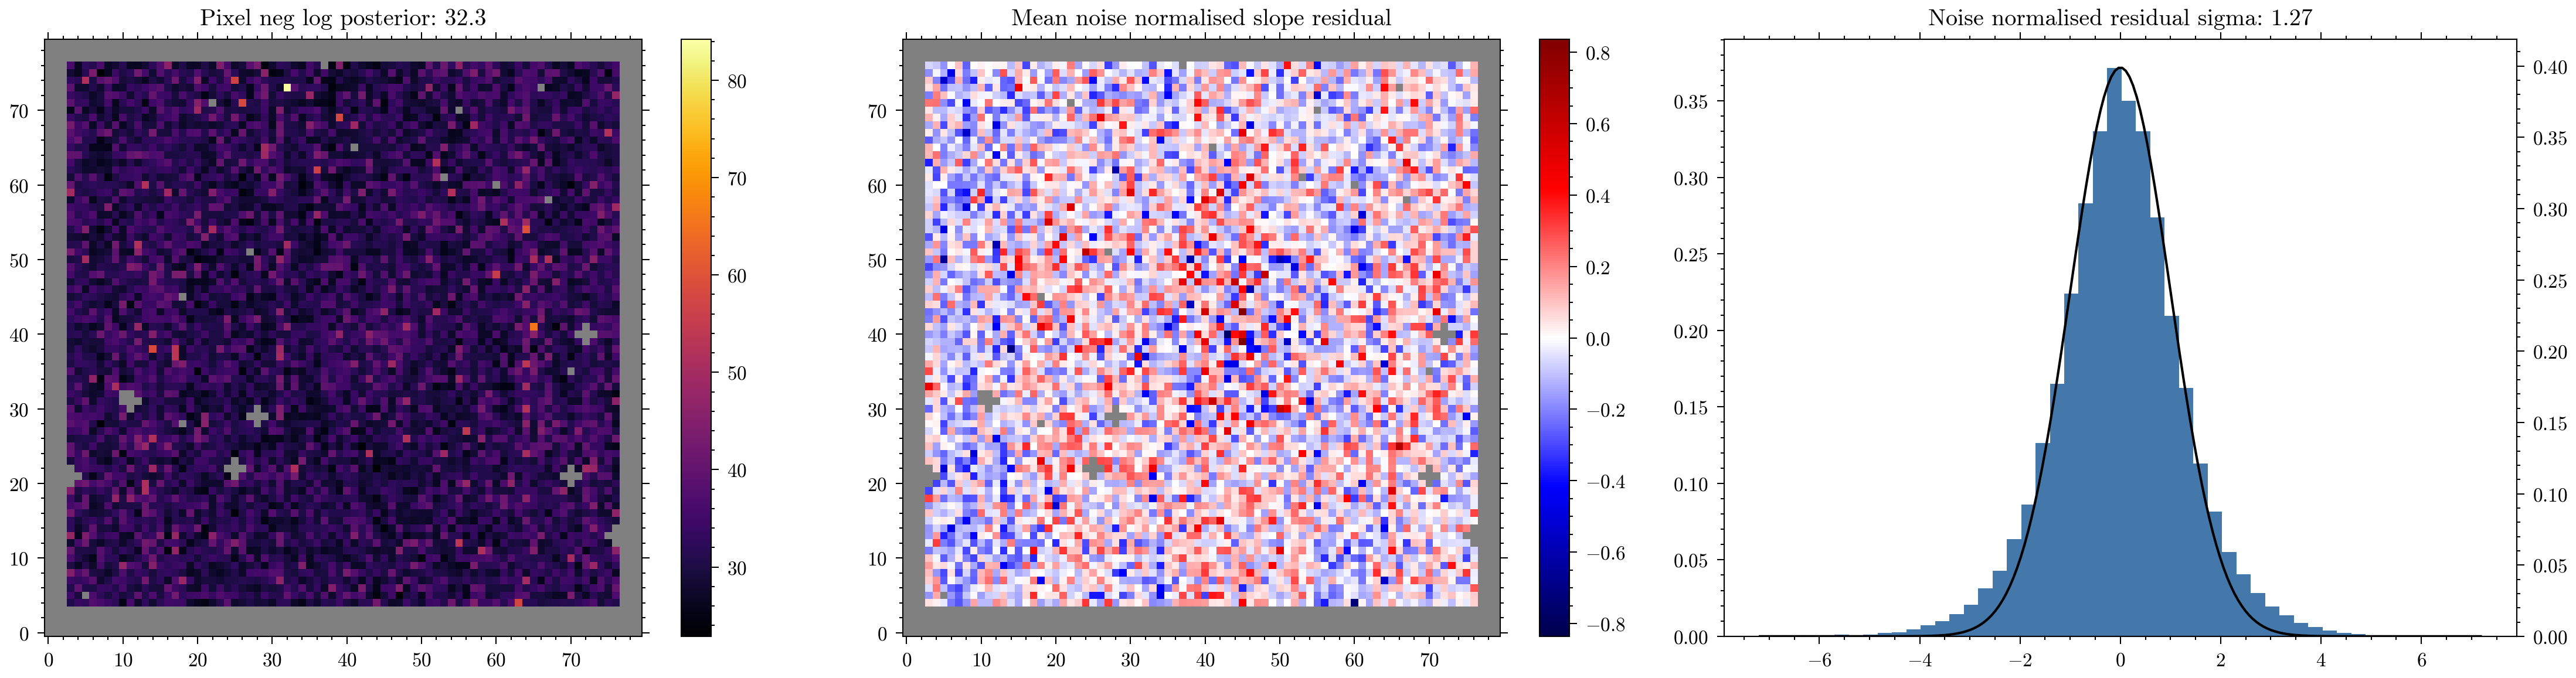

File 01373_023_02_03_2
Star HD 2236
Filter F430M
nints 8
ngroups 12



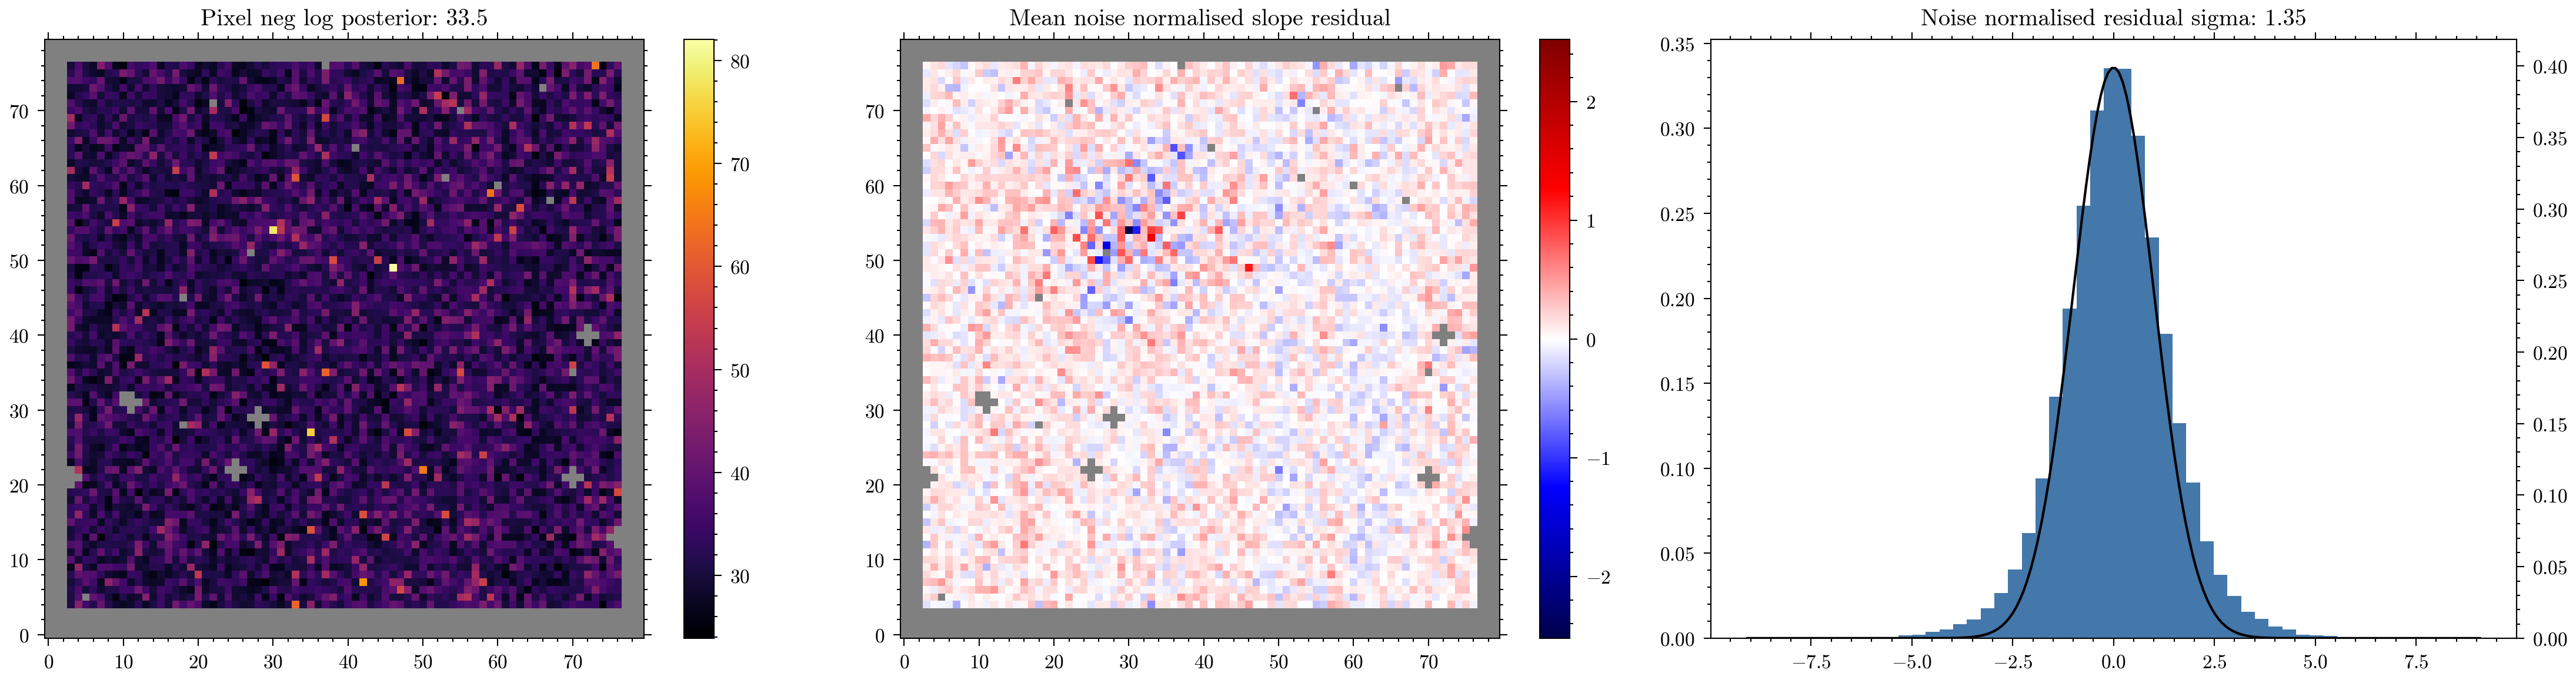

File 01373_023_02_03_3
Star HD 2236
Filter F430M
nints 8
ngroups 12



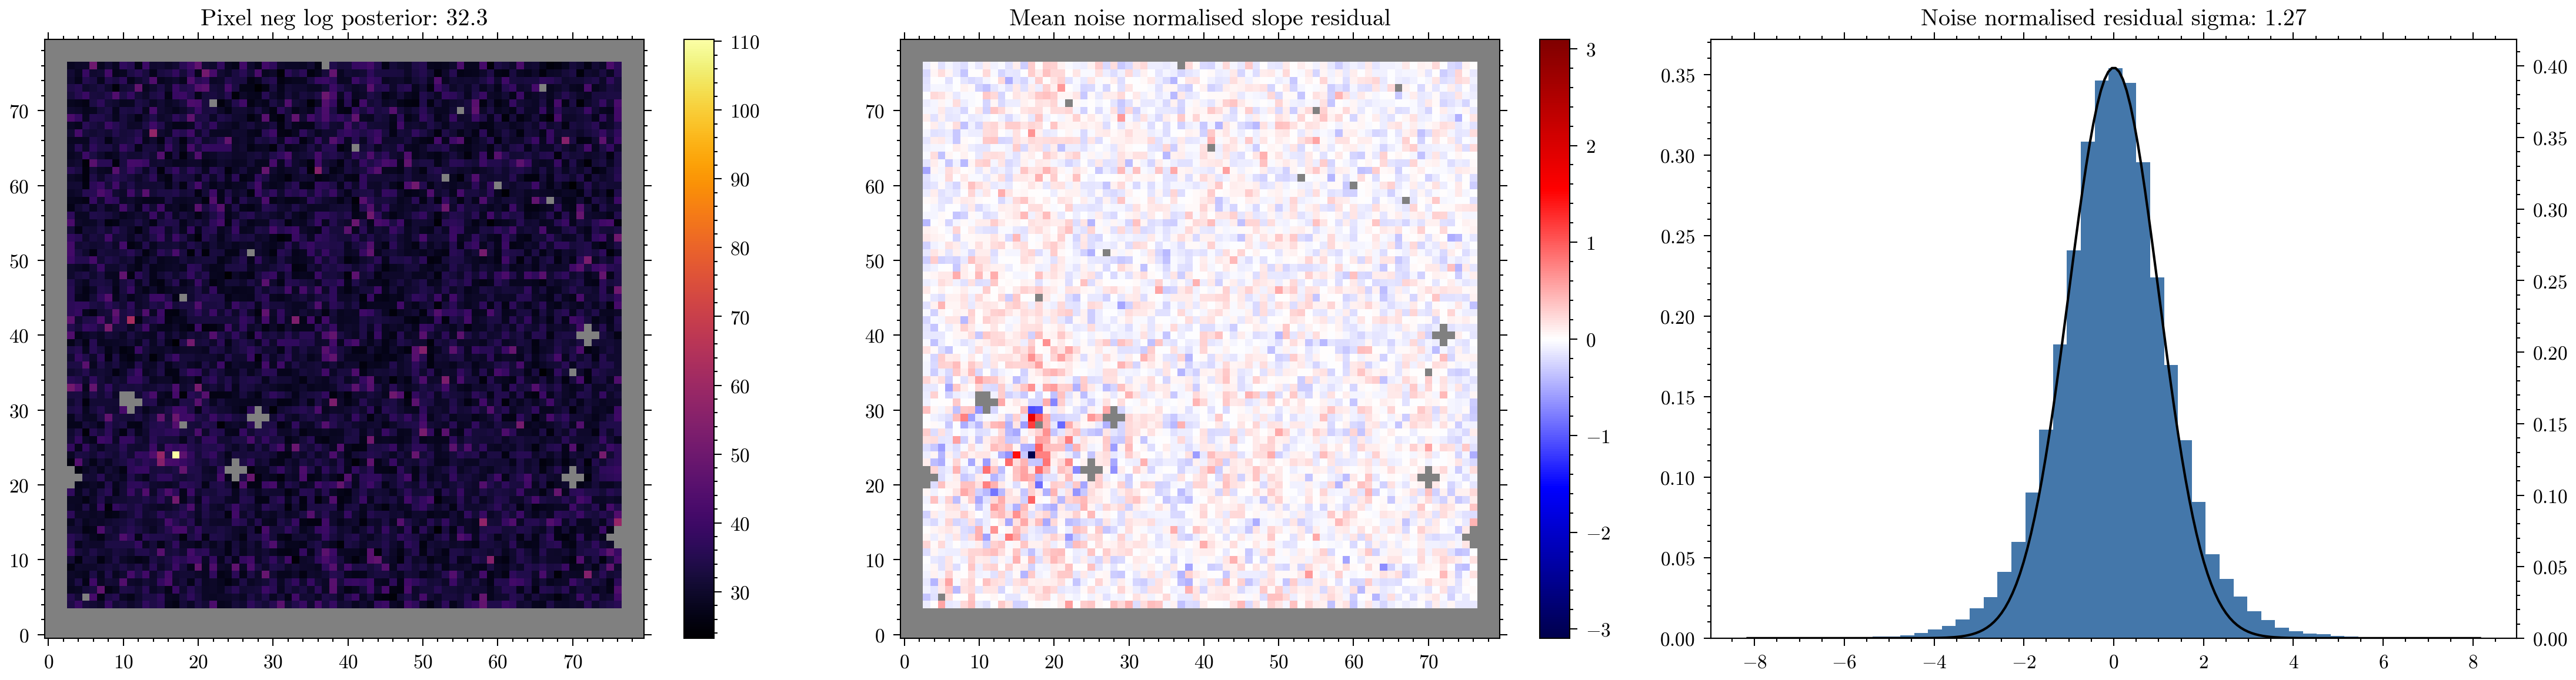

File 01373_023_02_03_4
Star HD 2236
Filter F430M
nints 8
ngroups 12



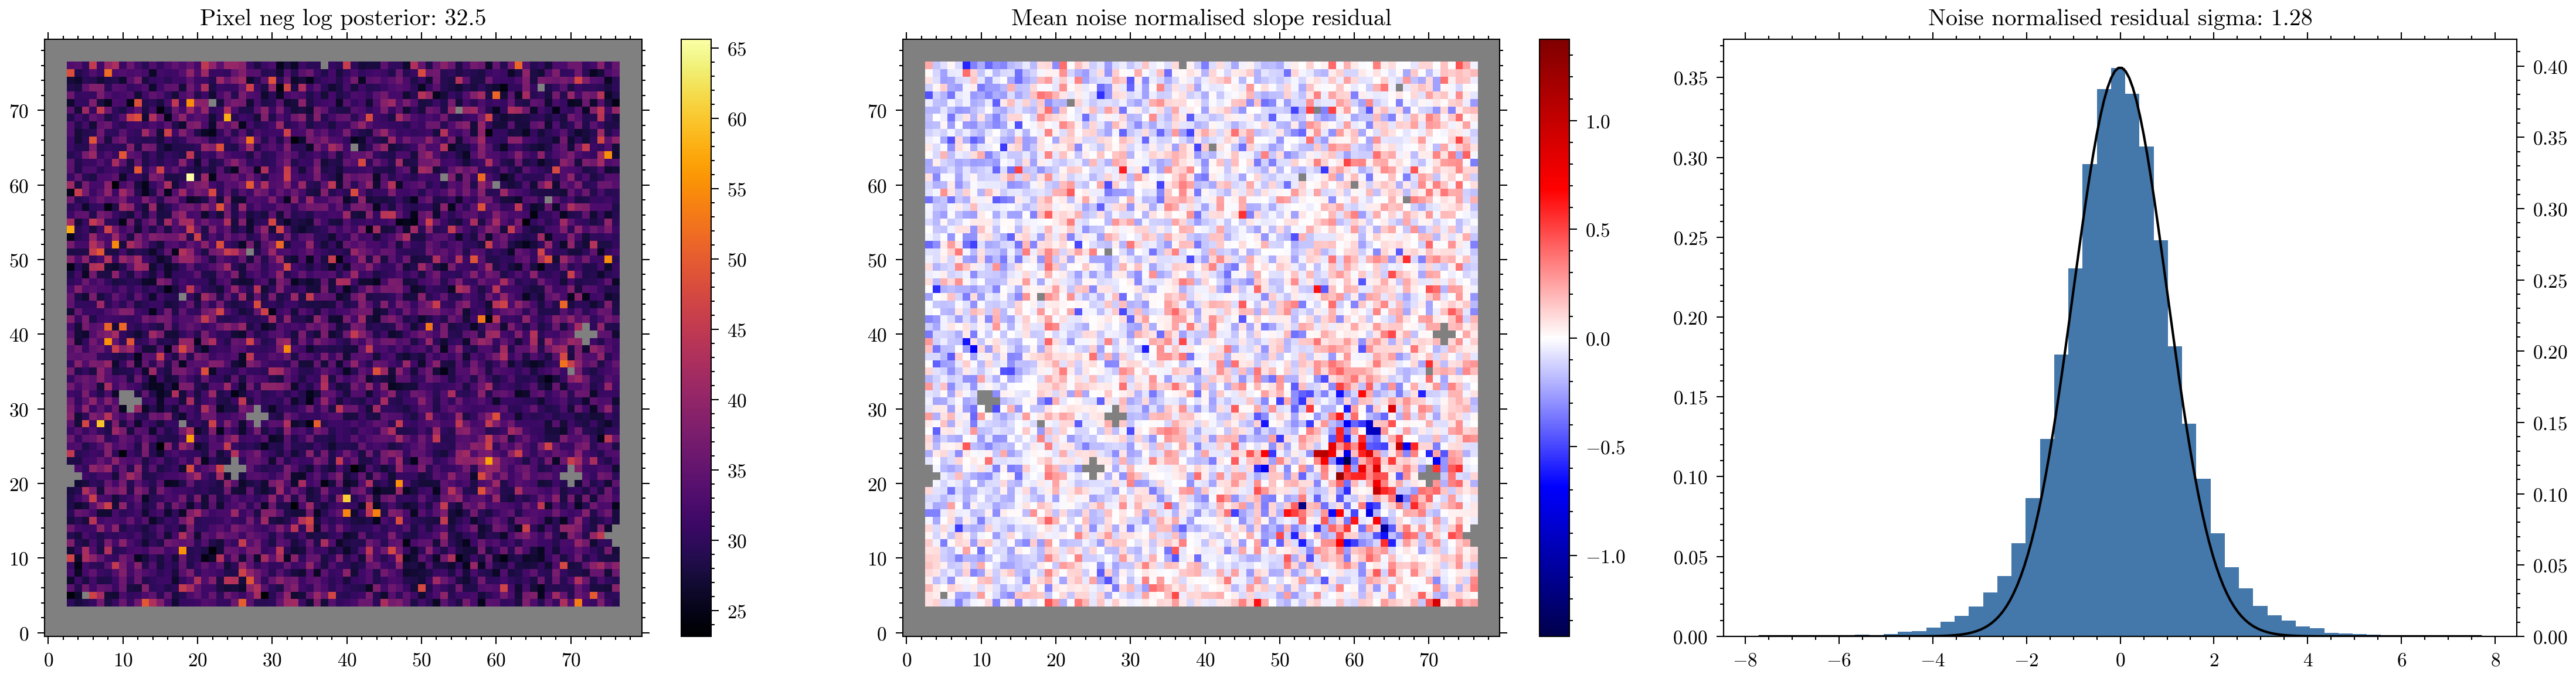

File 01373_017_02_04_1
Star IO
Filter F430M
nints 100
ngroups 18



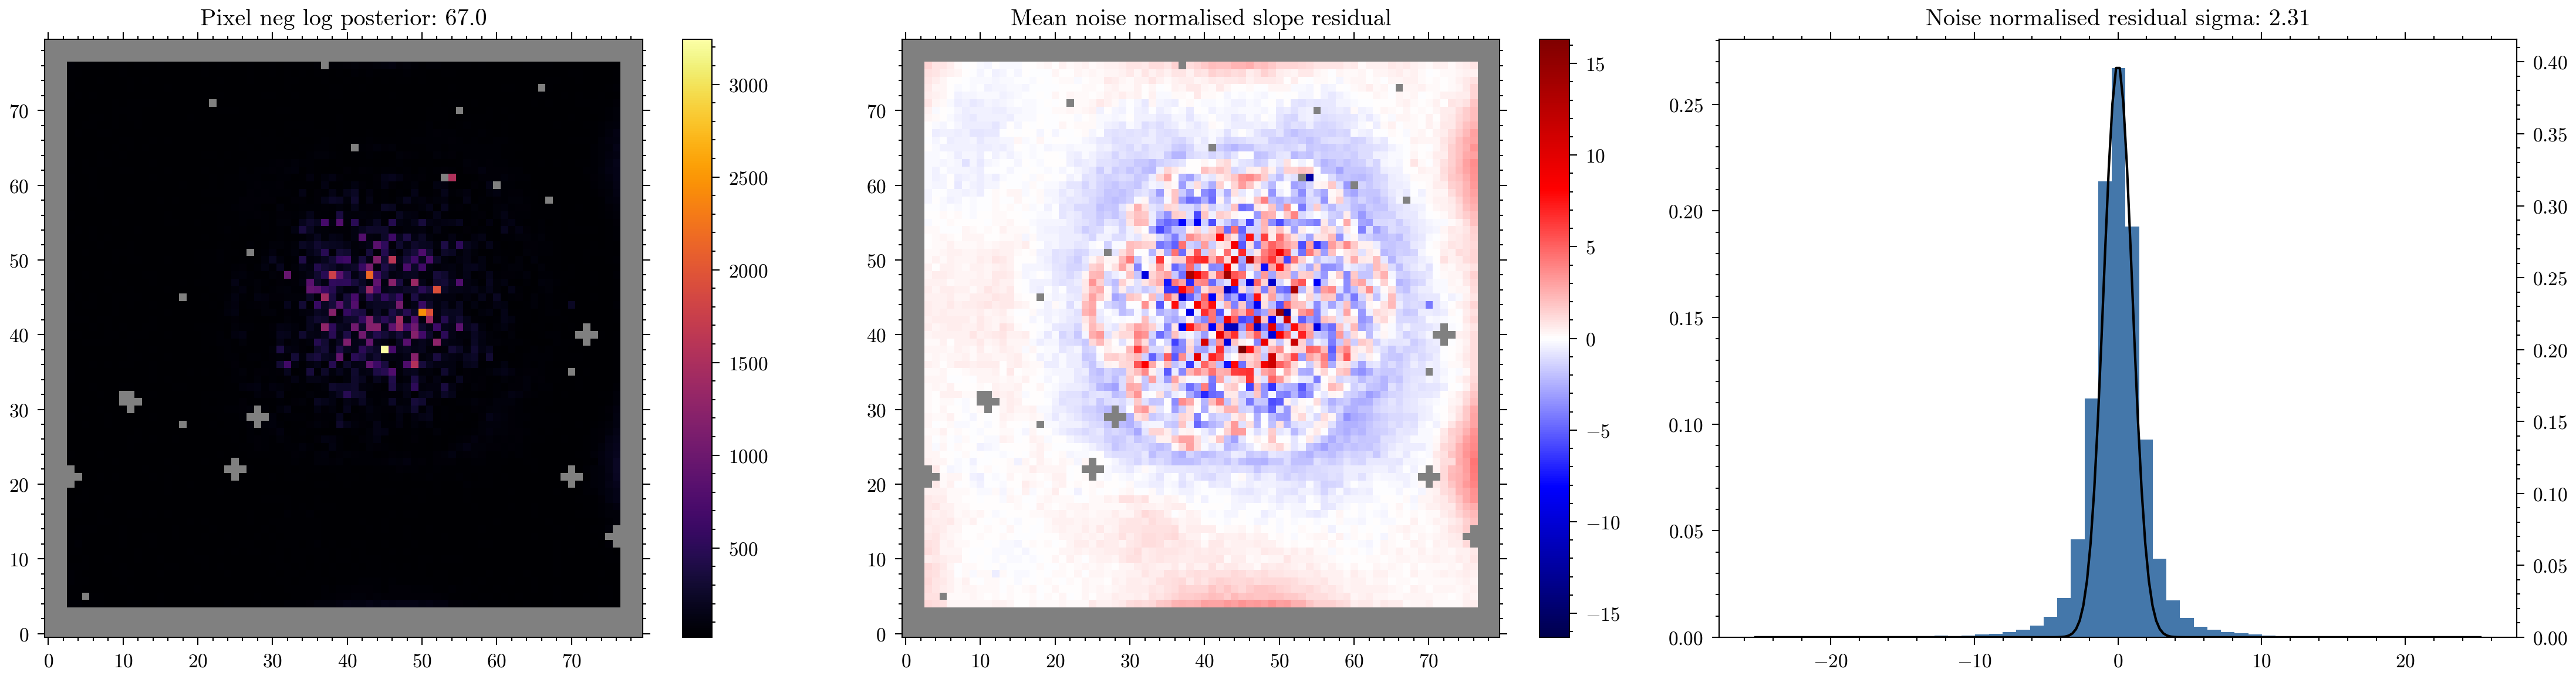

File 01373_017_02_04_2
Star IO
Filter F430M
nints 100
ngroups 18



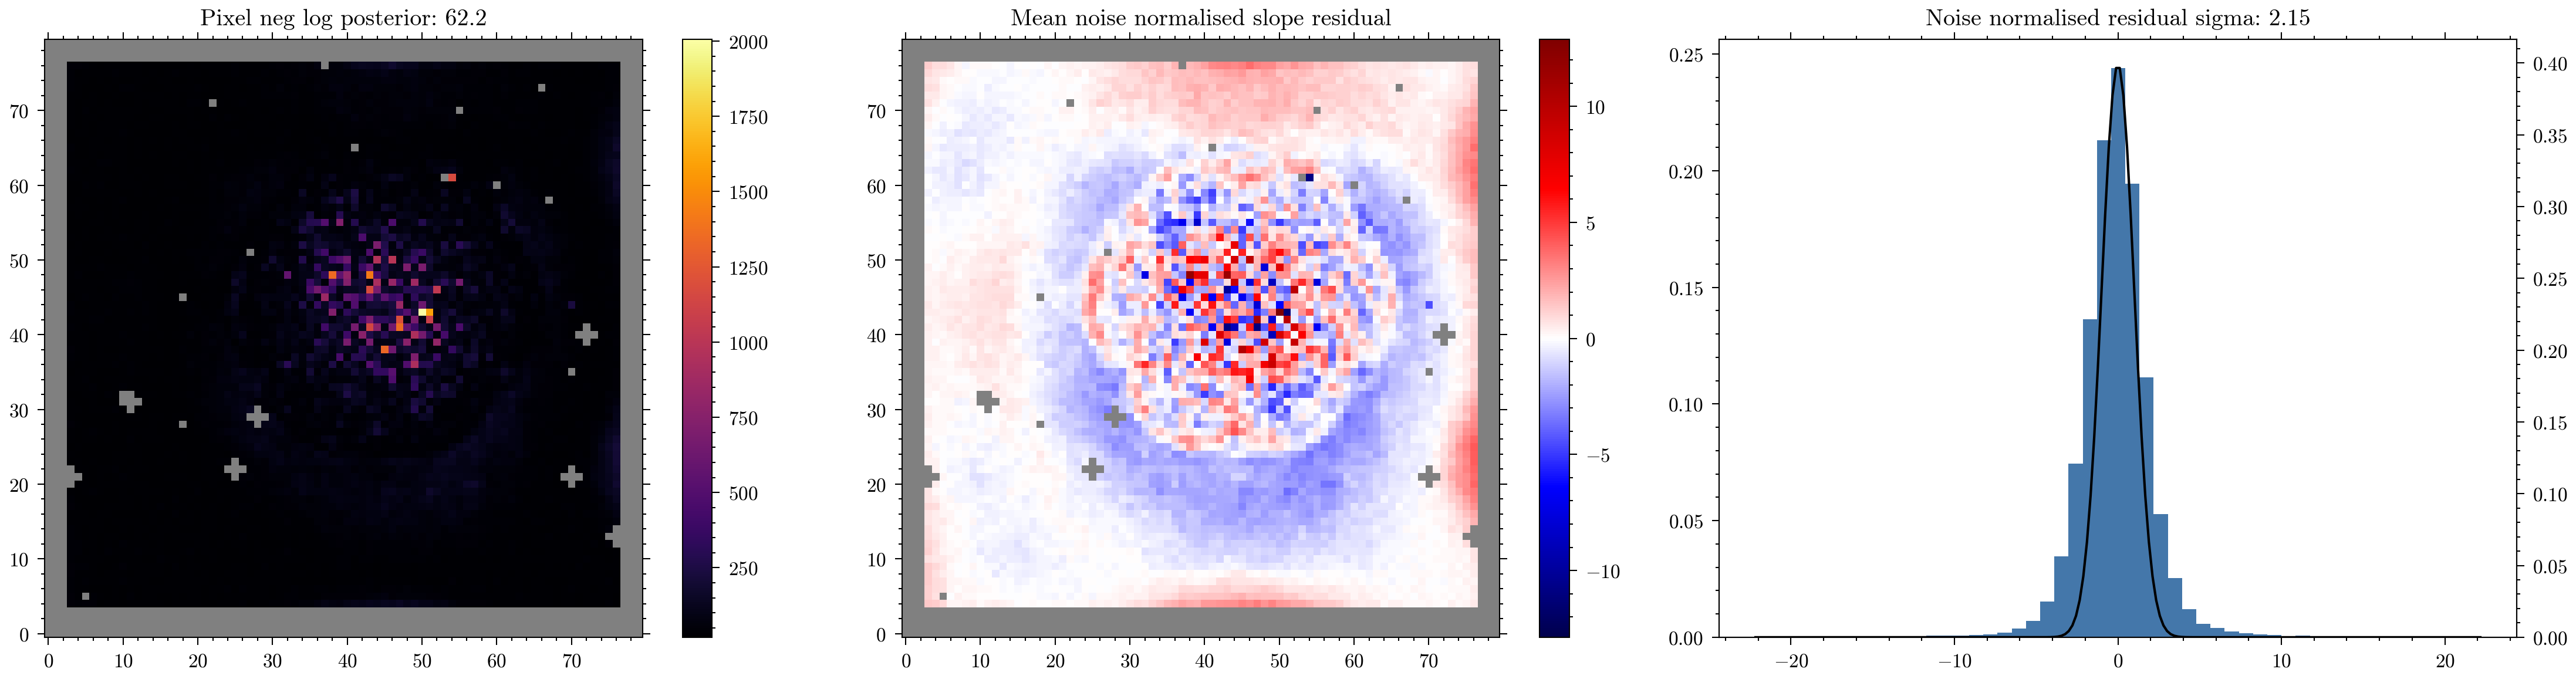

File 01373_017_02_04_3
Star IO
Filter F430M
nints 100
ngroups 18



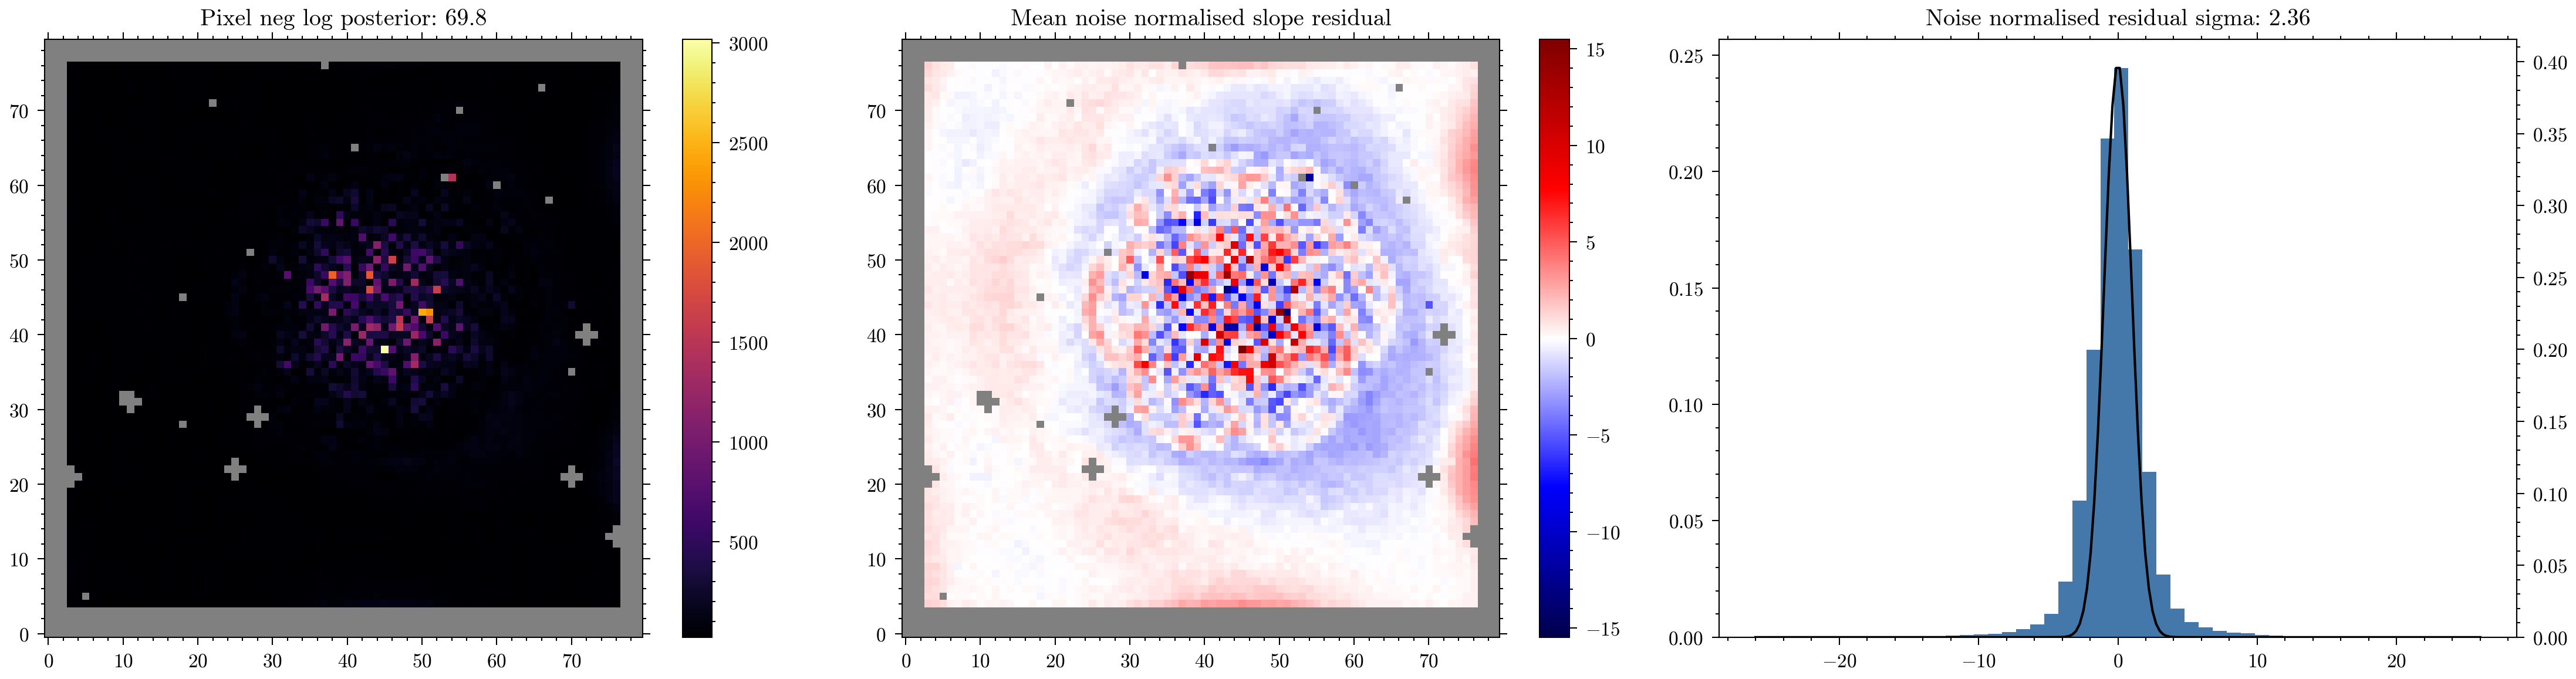

File 01373_017_02_04_4
Star IO
Filter F430M
nints 100
ngroups 18



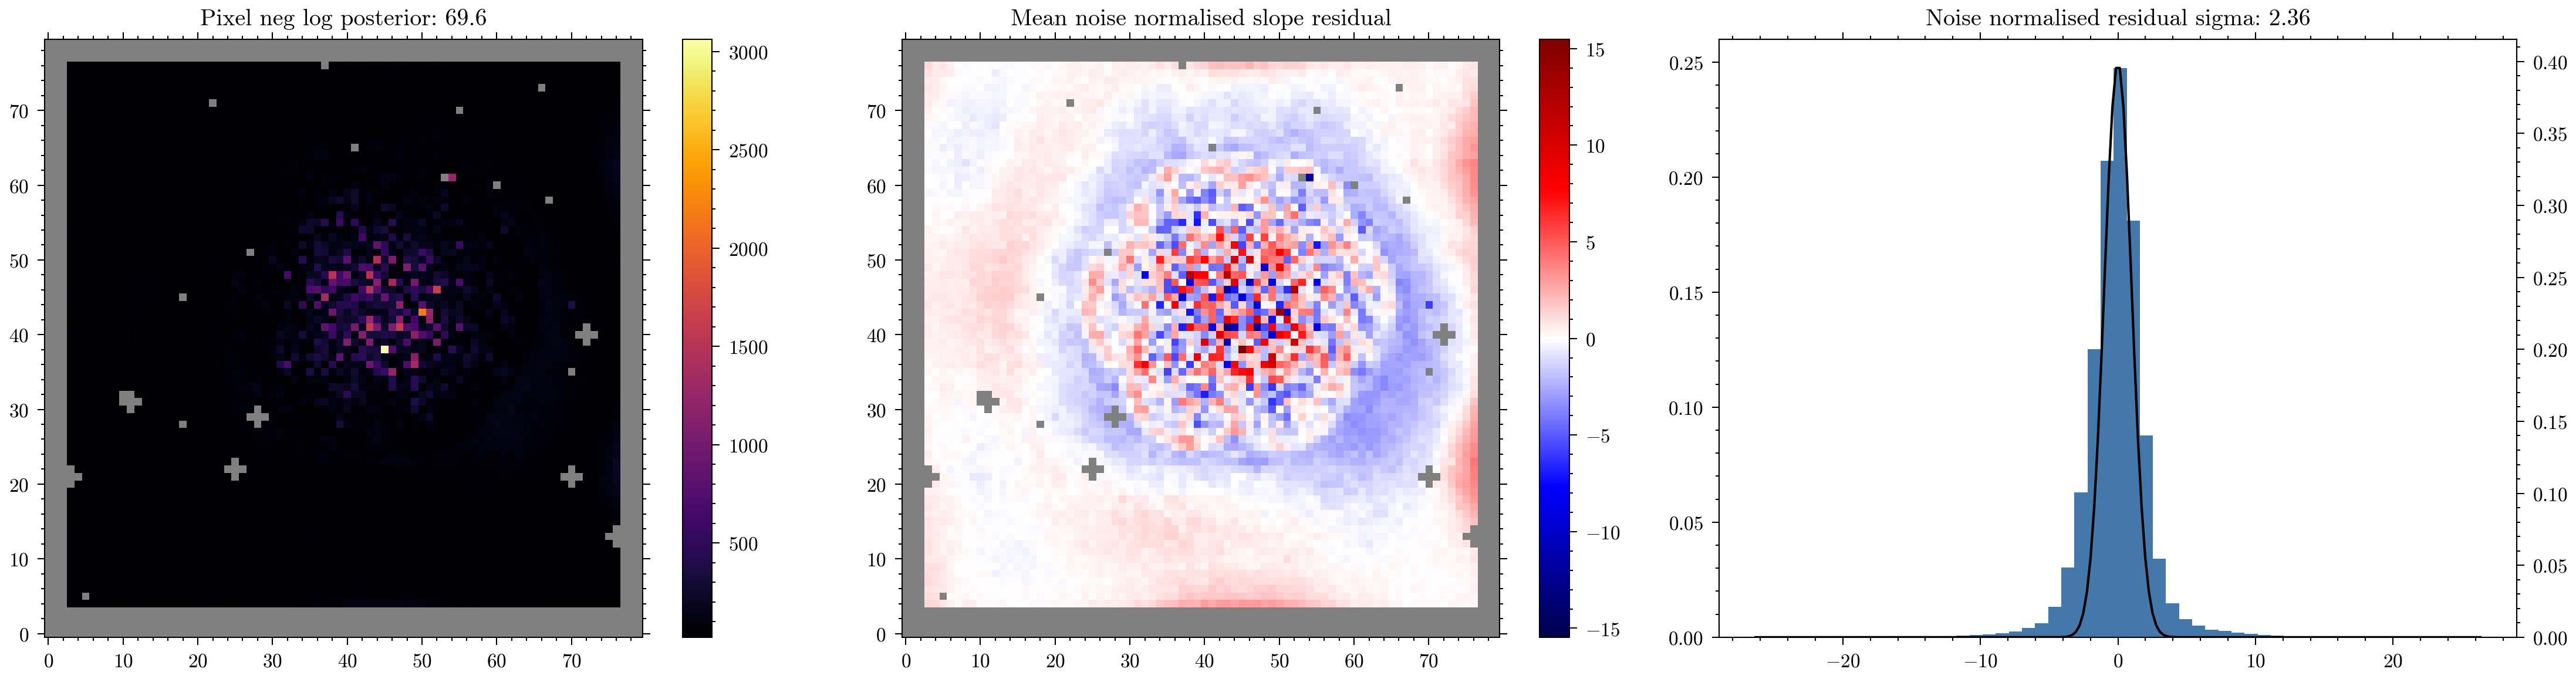

File 01373_017_02_04_5
Star IO
Filter F430M
nints 100
ngroups 18



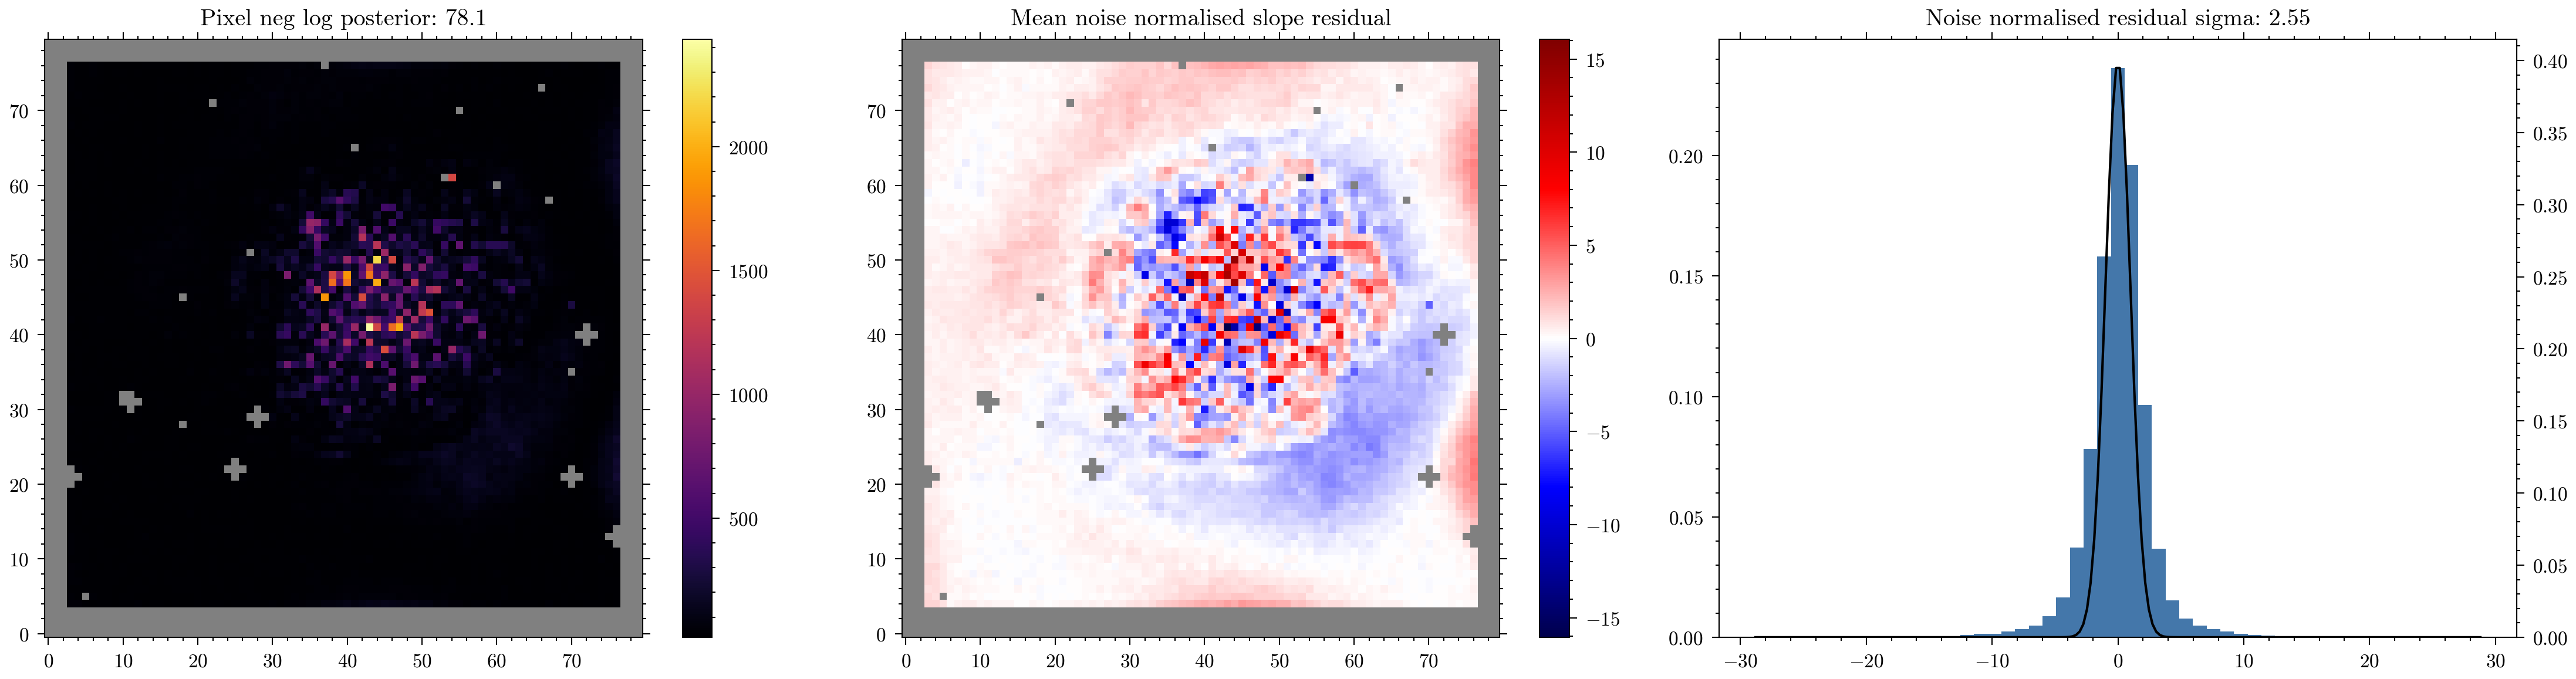

In [16]:
# np.save(init_state_cache + "5x150.npy", result.model.params)
result_model = result.model

# params = np.load(init_state_cache + "3x150.npy", allow_pickle=True).item()
# result_model = model.set("params", params)


summarise_reconstruction(result_model, fits, result=result)

In [17]:
import planetmapper
import scipy

features = {
    "seth": (132, -5.3),  # long [deg], lat [deg]
    # "masubi": (--56.18, -49.6),
    "P197": (108.8, -47.3),
    "masubi": (52.6, -45),
    "leizi": (44.93, 13.48),
    # "leizi": (-315.074, 13.48),
    "amirani": (115.2, 24.0),
    # "subobs": (--107.57361768, 2.60587485),
}
# https://iopscience.iop.org/article/10.3847/PSJ/ad4346/pdf


def plot_io_with_ephemeris(
    ax,
    array,
    exp,
    data_dir,
    pixel_scale,
    roll_angle_degrees=0.00,
    legend=False,
    points=None,
    **kwargs
):

    body = planetmapper.Observation(data_dir + exp.filename[:-5] + "_nis_uncal.fits")
    if points is not None:
        body.coordinates_of_interest_lonlat = points

    def coordinate_func(ra, dec):
        x, y = body.radec2angular(ra, dec)
        return -x, y

    body.plot_wireframe_custom(
        # body.plot_wireframe_angular(
        ax,
        coordinate_func=coordinate_func,
        # aspect_adjustable="box",
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=30,
        grid_lat_limit=75,
        formatting={
            # "limb": {
            #     "linestyle": "--",
            #     "linewidth": 0.8,
            #     "alpha": 0.8,
            #     "color": "white",
            # },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.3,
                "color": "k",
            },
            "equator": {
                "color": "r",
                "linewidth": 1,
                "color": "r",
                "label": "equator",
                # "alpha": 0.0,
            },
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.0,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "gold",
                "marker": "^",
                "facecolors": "none",
                # "markeredgecolor": "red",
                "s": 10,
                "label": "volcano",
            },
            "limb_illuminated": {"color": "b", "alpha": 0.0},
        },
    )

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper left",
        )

    im = plot_result(
        ax,
        array,
        pixel_scale=pixel_scale,
        roll_angle_degrees=roll_angle_degrees,
        show_diff_lim=True,
        **kwargs,
    )

    return im


def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = 0.0,
    model=None,
    show_diff_lim: bool = True,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    vmin: float = 0.0,
    vmax: float = None,
    power=0.5,
    contour=False,
    scale=1.0,
    translate=(0.0, 0.0),
):
    rotation_transform = (
        mpl.transforms.Affine2D()
        .translate(*translate)
        .rotate_deg(roll_angle_degrees)
        .scale(scale)
    )  # Create a rotation transformation

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=[0.5, 0, -0.5],
        yticks=[-0.5, 0, 0.5],
        **axis_labels,
    )  # Set the axis labels
    if model is not None:
        pixel_scale = model.psf_pixel_scale / model.optics.oversample / scale
        if show_diff_lim:
            ax = dorito.plotting.plot_diffraction_limit(model, ax, OOP=True)

    kwargs = {
        "cmap": cmap,
        "extent": dorito.plotting.get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": mpl.colors.PowerNorm(power, vmin=vmin, vmax=vmax),
        "aspect": "equal",
    }
    if contour:
        im = ax.contour(
            array,
            linewidths=0.5,
            levels=array.max() * np.linspace(0, 1, 10) ** 2,
            **kwargs,
        )
    else:
        im = ax.imshow(array, interpolation="bilinear", **kwargs)

    ax.axis("equal")
    trans_data = rotation_transform + ax.transData  # creating transformation
    im.set_transform(trans_data)  # applying transformation to image

    return im


def compute_com_physical(array, pixel_scale):
    """
    Compute the center of mass of a 2D array, assuming the center of the array is at (0, 0).

    Parameters:
    - array: 2D numpy array representing the mass distribution.
    - pixel_scale: The physical scale of each pixel (e.g., in units per pixel).

    Returns:
    - com_physical: The center of mass in physical coordinates, assuming (0, 0) at the center of the array.
    """
    # Compute the center of mass in pixel indices
    com_index = np.array(scipy.ndimage.center_of_mass(numpy.array(array)))

    # Calculate the center of the array in pixel indices
    array_center = np.array(array.shape) / 2 - 0.5  # (rows/2 - 0.5, cols/2 - 0.5)

    # Convert to physical coordinates
    com_physical = (com_index - array_center) * pixel_scale

    return np.array(
        [-com_physical[1], com_physical[0]]
    )  # Return (x, y) in physical coordinates

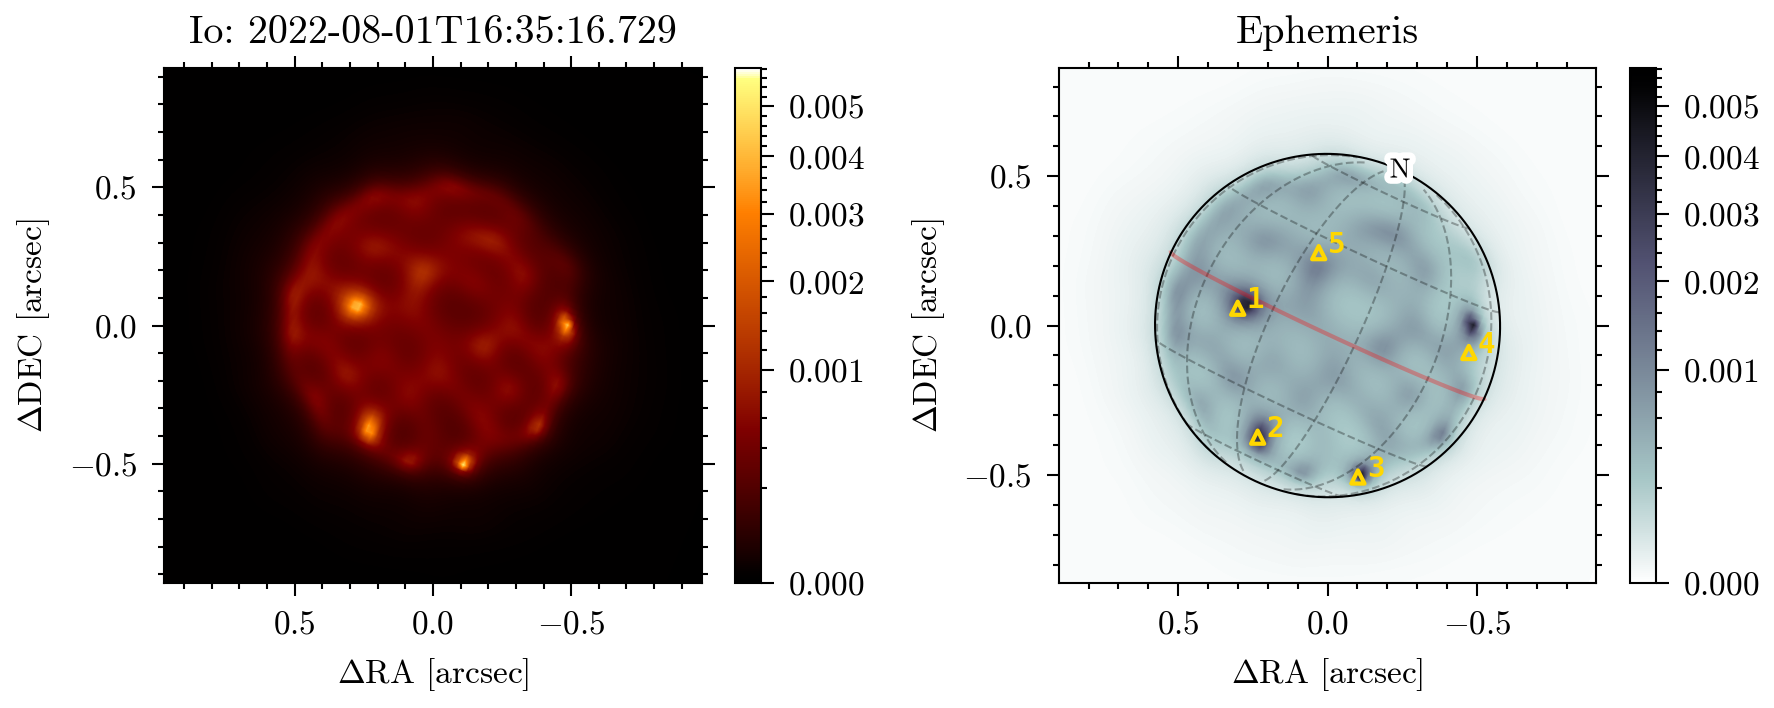

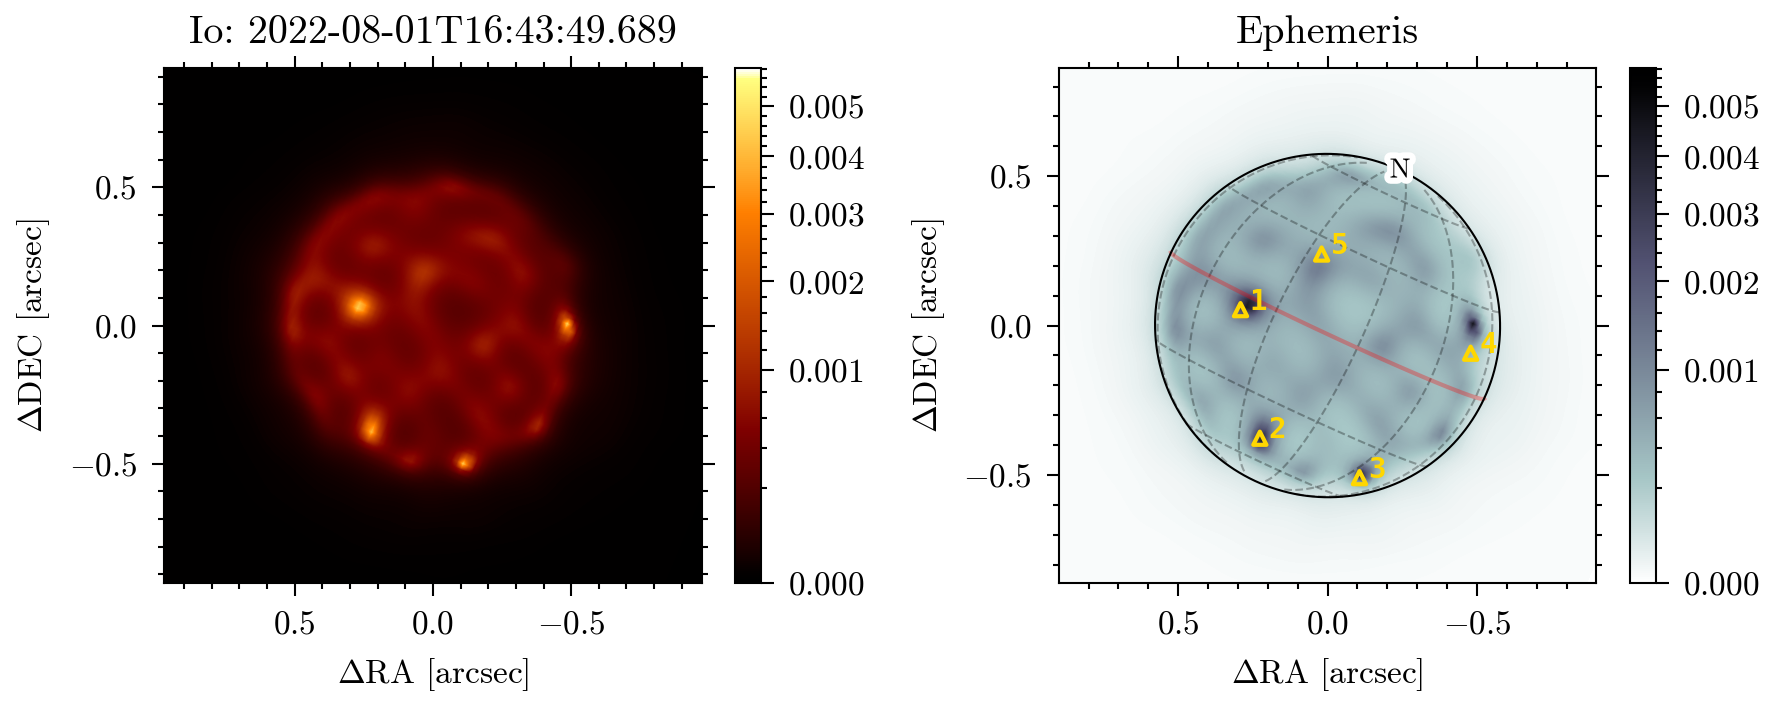

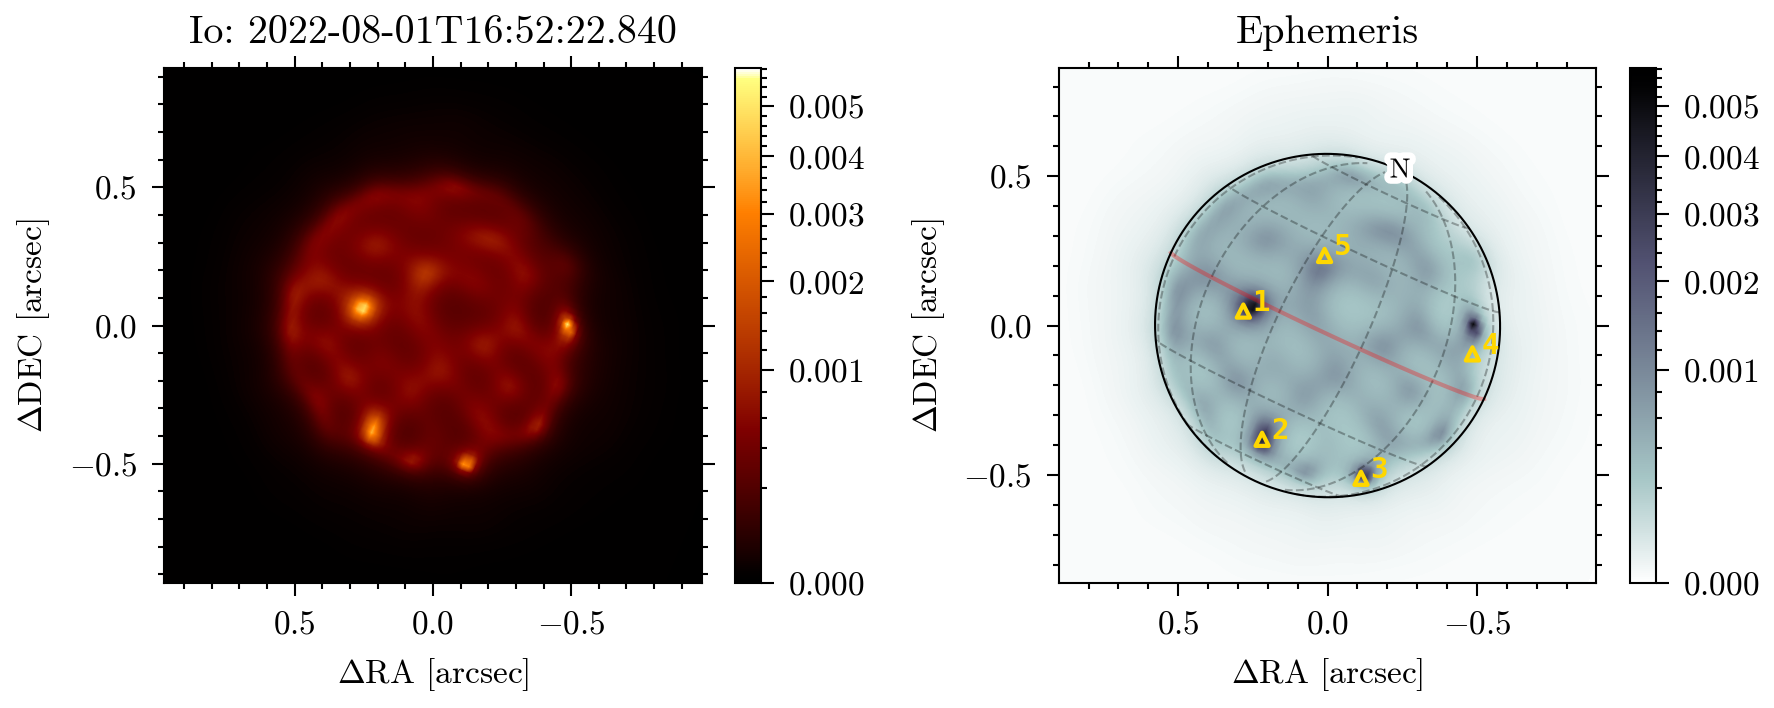

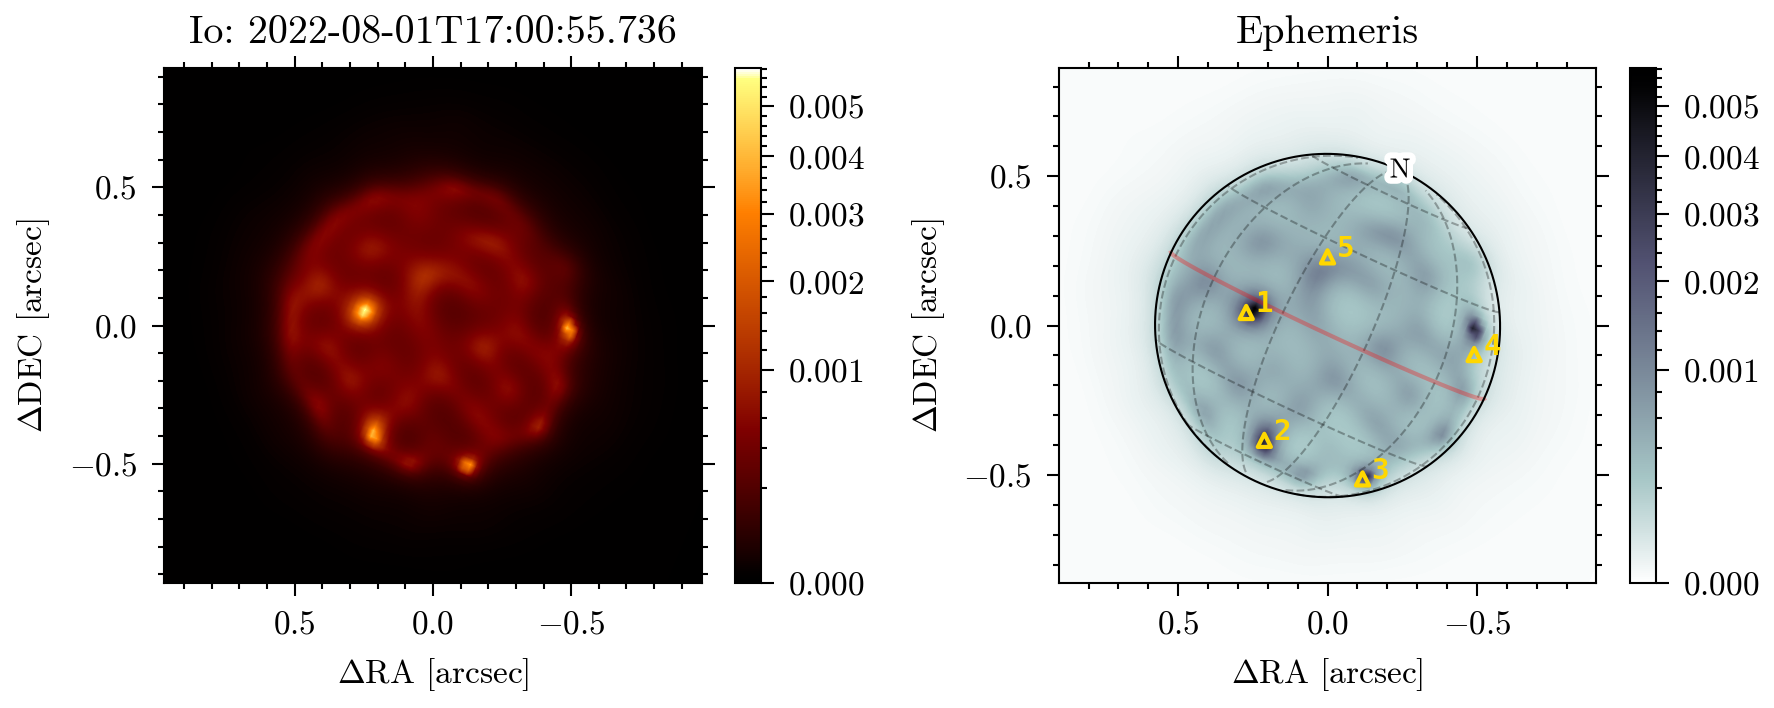

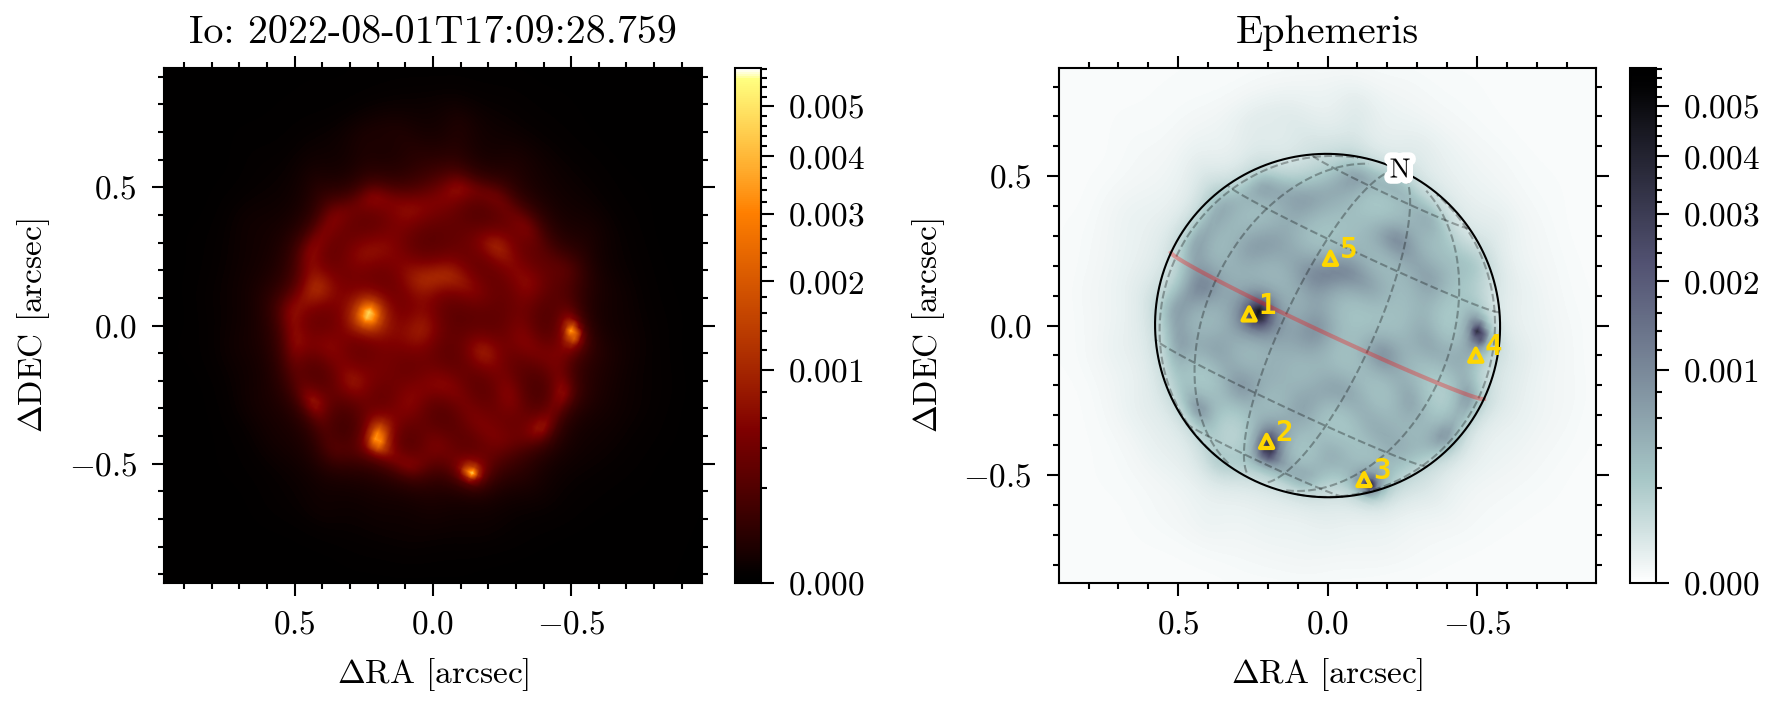

In [21]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")

import astropy
import scipy
import numpy

io_peak_flux = np.array([result_model.get_distribution(exp) for exp in sci_fits]).max()
clip_value = 0.001

save_dir = "gifs/spinning_io/"
for exp, file in zip(sci_fits, sci_files):

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd").isot
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5))
    c0 = plot_result(
        ax[0],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-rolls[exp.filename],
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        ax[1],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-rolls[exp.filename],
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    eps = 3e-2
    for i, (x, y) in enumerate(coords):  # i should now correctly track the index
        ax[1].text(
            x - eps,
            y,
            f"{i+1}",
            fontsize=7,
            c="gold",
            fontfamily="monospace",
            fontweight="bold",
        )  # Use i in the label

    fig.colorbar(c0)
    ax[0].set_title(f"Io: {time}")
    ax[1].set_title(f"Ephemeris")
    plt.tight_layout()
    fig.colorbar(c1, ax=ax[1])
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

In [24]:
formats = [
    "jd",
    "mjd",
    "decimalyear",
    "unix",
    "unix_tai",
    "cxcsec",
    "gps",
    "plot_date",
    "stardate",
    "datetime",
    "ymdhms",
    "iso",
    "isot",
    "yday",
    "datetime64",
    "fits",
    "byear",
    "jyear",
    "byear_str",
    "jyear_str",
]

time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")

list(time.ymdhms)[-3:]


def convert_time(time):

    if type(time) == str:
        time = astropy.time.Time(str(time, format="mjd"))

    t = list(time.ymdhms)[-3:]

    return f"{t[0]:02d}h {t[1]:02d}m {t[2]:.0f}s"


# convert_time(rang[0])

In [25]:
def get_exposing(files, eps=1e0, samples=1e4):

    starts = []
    ends = []
    for file in files:

        # print(file[0].header)
        start = astropy.time.Time(file[0].header["EXPSTART"], format="mjd")
        end = astropy.time.Time(file[0].header["EXPEND"], format="mjd")

        starts.append(mins_past_the_hour(start.mjd))
        ends.append(mins_past_the_hour(end.mjd))

    starts = np.array(starts)
    ends = np.array(ends)
    rang = np.linspace(starts.min() - eps, ends.max() + eps, int(samples))

    exposings = np.array(
        [
            np.where(rang > start, 1.0, 0.0) * np.where(rang < end, 1.0, 0.0)
            for start, end in zip(starts, ends)
        ]
    )

    return rang, exposings


def mins_past_the_hour(mjd):
    # Reference time: 5:00 PM (17:00) on August 1st, 2022 UTC
    ref_time = astropy.time.Time("2022-08-01 16:00:00", format="iso", scale="utc")

    # Convert input MJD to an astropy Time object
    current_time = astropy.time.Time(mjd, format="mjd", scale="utc")

    # Compute time difference in minutes
    delta_minutes = (current_time - ref_time).to("min").value

    return delta_minutes

/tmp/ipykernel_756793/3377626479.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


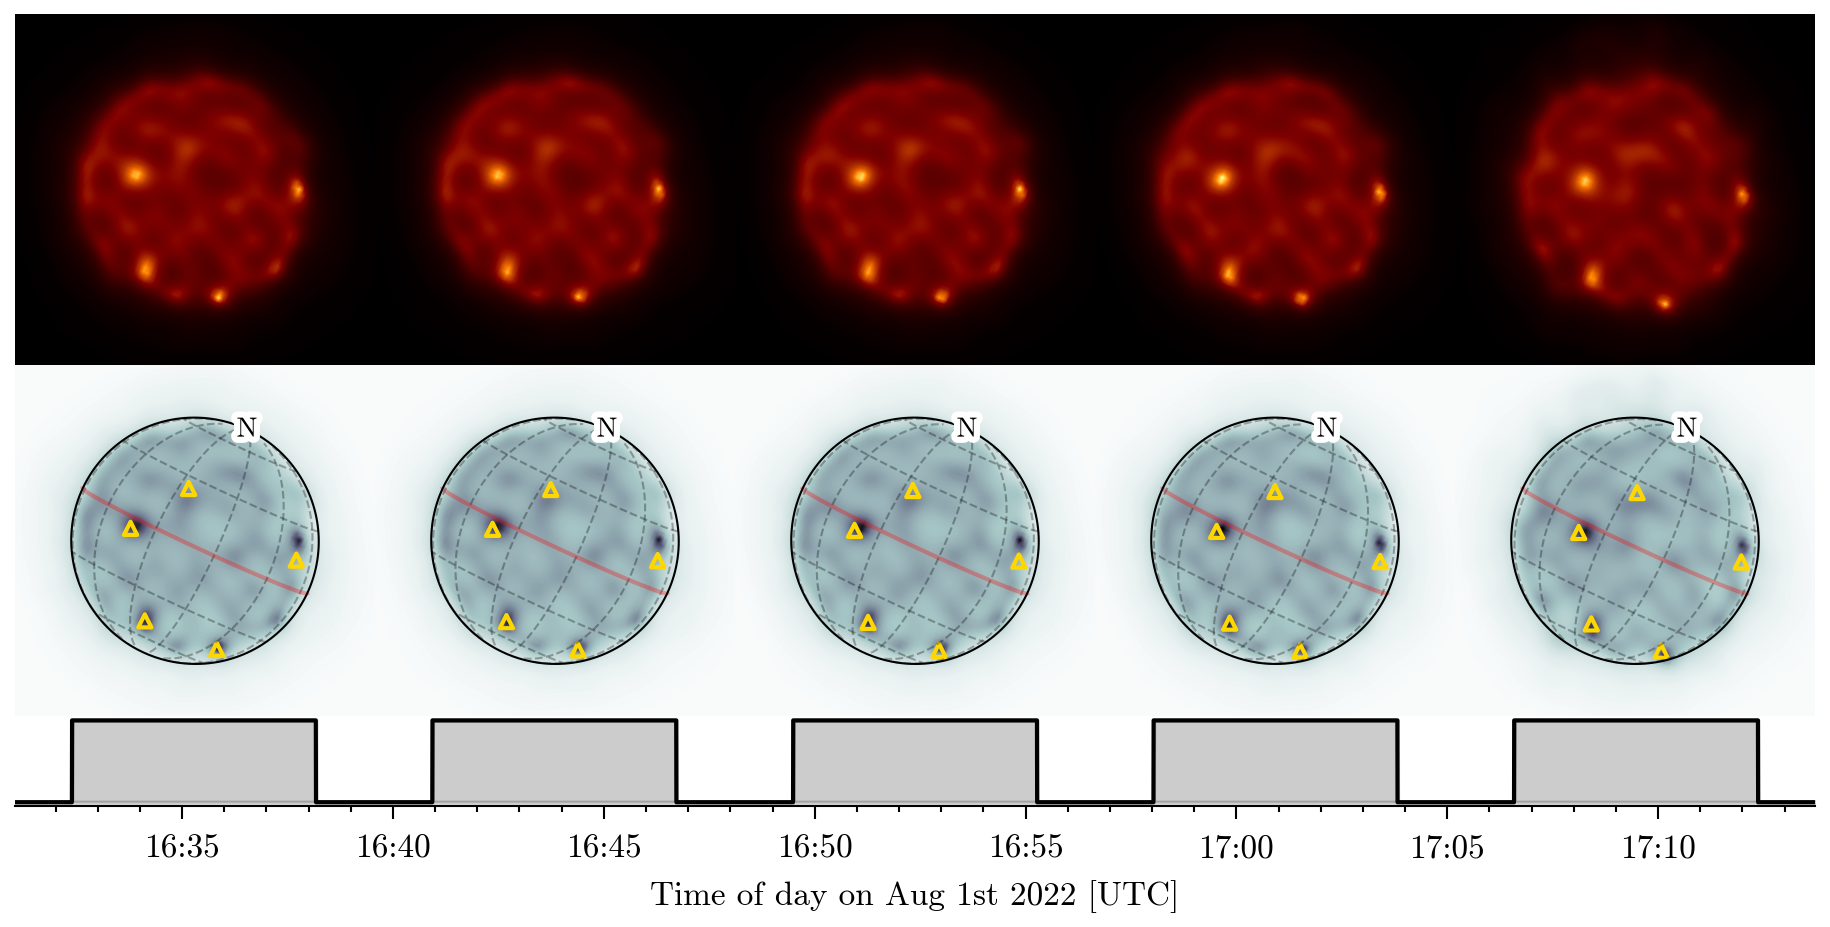

In [27]:
%matplotlib inline

rang, exposings = get_exposing(sci_files, eps=1.35)
exposing = np.sum(exposings, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(6, 3), gridspec_kw={"hspace": 0.0, "wspace": 0.0, "left":0, "right":1.})

# Adjust layout first
plt.tight_layout()

fig.subplots_adjust(bottom=0.1)  # Shift everything up to leave space for time axis

# Create a new axes for the time plot — [left, bottom, width, height] in figure fraction
time_ax = fig.add_axes([0., 0.0, 1., .1])  # Tune values if needed

for col, exp, file in zip(range(len(sci_fits)), sci_fits, sci_files):

    axes[0][col].axis("off")
    axes[1][col].axis("off")

    dist = result_model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd")
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        result_model.psf_pixel_scale / result_model.oversample,
    )

    # axes[0][col].set(title=convert_time(time))

    c0 = plot_result(
        axes[0][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-rolls[exp.filename],
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        axes[1][col],
        dist,
        pixel_scale=result_model.psf_pixel_scale / result_model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-rolls[exp.filename],
        scale=source_size / 75.0,
    )

    # Labelling volcanoes
    coords = []
    for artist in ax[1].collections:
        if hasattr(artist, "get_offsets"):
            coord = artist.get_offsets()[0]
            coords.append(coord)

    # eps = 3e-2
    # for i, (x, y) in enumerate(coords):  # i should now correctly track the index
    #     axes[1][col].text(
    #         x - eps,
    #         y,
    #         f"{i+1}",
    #         fontsize=7,
    #         c="gold",
    #         fontfamily="monospace",
    #         fontweight="bold",
    #     )  # Use i in the label

time_ax.plot(rang, exposing, 'k')
time_ax.fill_between(rang, exposing, color='k', alpha=0.2)
time_ax.spines['top'].set_visible(False)
time_ax.spines['right'].set_visible(False)
time_ax.spines['left'].set_visible(False)
time_ax.tick_params(axis="x", which="both", top=False)
time_ax.set(
    xlim=(rang.min(), rang.max()),
    xlabel="Time of day on Aug 1st 2022 [UTC]",  # Set the x-axis label
    xticks=range(35, 75, 5),
    xticklabels=["16:35", "16:40", "16:45", "16:50", "16:55", "17:00", "17:05", "17:10"],
    yticks=[],
    )


    # time_ax.axis("off")

plt.show()

# plt.show()